# 1. Cargar datos y librerias

Importar las librerías necesarias y cargo los cuatro archivos CSV en DataFrames de pandas.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, ttest_ind
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Cargar los datos
marketing_events = pd.read_csv('datasets/ab_project_marketing_events_us.csv')
new_users = pd.read_csv('datasets/final_ab_new_users_upd_us.csv')
events = pd.read_csv('datasets/final_ab_events_upd_us.csv')
participants = pd.read_csv('datasets/final_ab_participants_upd_us.csv')

print("--- Datos cargados correctamente ---")
print(f"Marketing events: {marketing_events.shape}")
print(f"New users: {new_users.shape}")
print(f"Events: {events.shape}")
print(f"Participants: {participants.shape}")

--- Datos cargados correctamente ---
Marketing events: (14, 4)
New users: (58703, 4)
Events: (423761, 4)
Participants: (14525, 3)


# 2. Limpieza y preparacion de datos

## 2.1 Convertir las fechas al formato datetime

In [3]:
# Convertir columnas de fecha a datetime
marketing_events['start_dt'] = pd.to_datetime(marketing_events['start_dt'])
marketing_events['finish_dt'] = pd.to_datetime(marketing_events['finish_dt'])
new_users['first_date'] = pd.to_datetime(new_users['first_date'])
events['event_dt'] = pd.to_datetime(events['event_dt'])

print("--- Fechas convertidas a datetime ---")
print(f"Marketing events - fechas convertidas: {marketing_events[['start_dt', 'finish_dt']].dtypes}")
print(f"New users - first_date convertida: {new_users['first_date'].dtype}")
print(f"Events - event_dt convertida: {events['event_dt'].dtype}")

--- Fechas convertidas a datetime ---
Marketing events - fechas convertidas: start_dt     datetime64[ns]
finish_dt    datetime64[ns]
dtype: object
New users - first_date convertida: datetime64[ns]
Events - event_dt convertida: datetime64[ns]


## 2.2 Verificacion de valores nulos

In [4]:
print("\nValores nulos en marketing_events:")
print(marketing_events.isnull().sum())

print("\nValores nulos en new_users:")
print(new_users.isnull().sum())

print("\nValores nulos en events:")
print(events.isnull().sum())

print("\nValores nulos en participants:")
print(participants.isnull().sum())


Valores nulos en marketing_events:
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64

Valores nulos en new_users:
user_id       0
first_date    0
region        0
device        0
dtype: int64

Valores nulos en events:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64

Valores nulos en participants:
user_id    0
group      0
ab_test    0
dtype: int64


## 2.3 Vertificacion de valores duplicados

In [5]:
print(f"Duplicados en marketing_events: {marketing_events.duplicated().sum()}")
print(f"Duplicados en new_users (por user_id): {new_users.duplicated(subset=['user_id']).sum()}")
print(f"Duplicados en events (todas las columnas): {events.duplicated().sum()}")
print(f"Duplicados en participants (user_id, ab_test): {participants.duplicated(subset=['user_id', 'ab_test']).sum()}")

Duplicados en marketing_events: 0
Duplicados en new_users (por user_id): 0
Duplicados en events (todas las columnas): 0
Duplicados en participants (user_id, ab_test): 0


### 2.3.1 Verificacion de usuarios en multiples grupos o tests

In [6]:
# Verificar si hay usuarios en más de un grupo del mismo test
double_group = participants.groupby('user_id')['group'].nunique()
users_in_both = double_group[double_group > 1].count()
print(f"Usuarios presentes en ambos grupos (A y B): {users_in_both}")

# Verificar si hay usuarios que participan en otro test simultáneo
test_counts = participants.groupby('user_id')['ab_test'].nunique()
users_in_multi_tests = test_counts[test_counts > 1].count()
print(f"Usuarios en multiples tests: {users_in_multi_tests}")

# Eliminar usuarios inválidos si es necesario
if users_in_both > 0:
    invalid_users = double_group[double_group > 1].index
    participants = participants[~participants['user_id'].isin(invalid_users)]
    print(f"  Se eliminaron {len(invalid_users)} usuarios inválidos")

Usuarios presentes en ambos grupos (A y B): 441
Usuarios en multiples tests: 887
  Se eliminaron 441 usuarios inválidos


## 2.3.2 -Analisis profundo de calidad de datos

In [7]:
# ============================================
# 2.4.1 - ANALISIS PROFUNDO DE CALIDAD DE DATOS
# ============================================

print("\n" + "="*70)
print("ANALISIS PROFUNDO DE CALIDAD DE DATOS")
print("="*70)

# Inicializar variables para evitar NameError
duplicate_count = 0
events_before_reg_count = 0
invalid_revenue_count = 0
users_without_events_count = 0
inconsistent_users_count = 0
out_of_range_count = 0
invalid_registrations_count = 0
unexpected_events = set()

# Verificar que las columnas necesarias existen
required_cols = ['user_id', 'event_dt', 'event_name', 'revenue_usd']
missing_cols = [col for col in required_cols if col not in events.columns]
if missing_cols:
    print(f"ERROR: Faltan columnas: {missing_cols}")
    print(f"Columnas disponibles: {events.columns.tolist()}")
else:
    print("Todas las columnas necesarias estan presentes")

# -----------------------------------------------------------------
# 1. VERIFICAR EVENTOS DUPLICADOS EXACTOS
# -----------------------------------------------------------------
print("\n1. VERIFICANDO EVENTOS DUPLICADOS EXACTOS")
print("-" * 50)

# Verificar si las columnas existen antes de usarlas
if 'user_id' in events.columns and 'event_dt' in events.columns and 'event_name' in events.columns and 'revenue_usd' in events.columns:
    duplicate_events = events.duplicated(subset=['user_id', 'event_dt', 'event_name', 'revenue_usd'], keep=False)
    duplicate_count = duplicate_events.sum()
    duplicate_percentage = (duplicate_count / len(events)) * 100
    
    print(f"Eventos duplicados exactos: {duplicate_count:,}")
    print(f"Porcentaje del total: {duplicate_percentage:.2f}%")
    
    if duplicate_count > 0:
        print("\nADVERTENCIA: Existen eventos duplicados exactos")
        print("   Ejemplo de duplicados:")
        duplicate_examples = events[duplicate_events].head(5)
        print(duplicate_examples[['user_id', 'event_dt', 'event_name', 'revenue_usd']].to_string(index=False))
        print("\n   Posibles causas: tracking duplicado, errores en la carga de datos")
    else:
        print("No se encontraron eventos duplicados exactos")
else:
    print("No se pueden verificar duplicados: faltan columnas necesarias")

# -----------------------------------------------------------------
# 2. VERIFICAR TIMESTAMPS FUERA DEL RANGO DE PRUEBA
# -----------------------------------------------------------------
print("\n2. VERIFICANDO TIMESTAMPS FUERA DEL RANGO DE PRUEBA")
print("-" * 50)

# Fechas de la prueba
test_start = pd.Timestamp('2020-12-07')
test_end = pd.Timestamp('2021-01-01')

# Asegurar que event_dt es datetime
if 'event_dt' in events.columns:
    if not pd.api.types.is_datetime64_any_dtype(events['event_dt']):
        events['event_dt'] = pd.to_datetime(events['event_dt'])
    
    # Eventos fuera del rango de prueba
    out_of_range = events[
        (events['event_dt'] < test_start) | 
        (events['event_dt'] > test_end)
    ]
    out_of_range_count = len(out_of_range)
    print(f"Eventos fuera del rango de prueba ({test_start.date()} a {test_end.date()}): {out_of_range_count:,}")
    
    if out_of_range_count > 0:
        print("\nADVERTENCIA: Eventos fuera del periodo de prueba")
        print("   Ejemplos:")
        print(out_of_range[['user_id', 'event_dt', 'event_name']].head(5).to_string(index=False))

# Eventos antes del registro (problema de integridad)
if 'user_id' in events.columns and 'first_date' in new_users.columns:
    if not pd.api.types.is_datetime64_any_dtype(new_users['first_date']):
        new_users['first_date'] = pd.to_datetime(new_users['first_date'])
    
    events_with_users = events.merge(new_users[['user_id', 'first_date']], on='user_id', how='left')
    events_before_reg = events_with_users[events_with_users['event_dt'] < events_with_users['first_date']]
    events_before_reg_count = len(events_before_reg)
    print(f"\nEventos que ocurrieron ANTES del registro del usuario: {events_before_reg_count:,}")
    
    if events_before_reg_count > 0:
        print("   ADVERTENCIA: Esto indica problemas de integridad en los datos")
        print("   Ejemplos:")
        print(events_before_reg[['user_id', 'event_dt', 'first_date', 'event_name']].head(5).to_string(index=False))

# -----------------------------------------------------------------
# 3. VERIFICAR REVENUE INVALIDO EN COMPRAS
# -----------------------------------------------------------------
print("\n3. VERIFICANDO REVENUE EN EVENTOS DE COMPRA")
print("-" * 50)

if 'revenue_usd' in events.columns:
    # Compras con revenue negativo o cero
    purchases = events[events['event_name'] == 'purchase'].copy()
    invalid_revenue_df = purchases[purchases['revenue_usd'] <= 0]
    invalid_revenue_count = len(invalid_revenue_df)
    print(f"Total de compras: {len(purchases):,}")
    print(f"Compras con revenue invalido (<= 0): {invalid_revenue_count:,}")
    
    if invalid_revenue_count > 0:
        invalid_percentage = (invalid_revenue_count / len(purchases)) * 100
        print(f"Porcentaje de compras invalidas: {invalid_percentage:.2f}%")
        print("\nADVERTENCIA: Existen compras con revenue invalido")
        print("   Ejemplos:")
        print(invalid_revenue_df[['user_id', 'event_dt', 'revenue_usd']].head(5).to_string(index=False))
    
    # Verificar valores atipicos en revenue
    print("\nEstadisticas de revenue en compras validas:")
    valid_purchases = purchases[purchases['revenue_usd'] > 0]['revenue_usd']
    if len(valid_purchases) > 0:
        print(f"  - Minimo: ${valid_purchases.min():.2f}")
        print(f"  - Maximo: ${valid_purchases.max():.2f}")
        print(f"  - Media: ${valid_purchases.mean():.2f}")
        print(f"  - Mediana: ${valid_purchases.median():.2f}")
        
        # Verificar si hay valores no estandar
        standard_values = [4.99, 9.99, 99.99, 499.99]
        non_standard = valid_purchases[~valid_purchases.isin(standard_values)]
        print(f"\nCompras con valores NO estandar: {len(non_standard):,}")
        
        if len(non_standard) > 0:
            print("   Valores encontrados:")
            print(non_standard.value_counts().head(10))
    else:
        print("  No hay compras validas para analizar")

# -----------------------------------------------------------------
# 4. VERIFICAR CONSISTENCIA DE FECHAS DE REGISTRO
# -----------------------------------------------------------------
print("\n4. VERIFICANDO CONSISTENCIA DE REGISTRO DE USUARIOS")
print("-" * 50)

registration_start = pd.Timestamp('2020-12-07')
registration_end = pd.Timestamp('2020-12-21')

if 'first_date' in new_users.columns:
    if not pd.api.types.is_datetime64_any_dtype(new_users['first_date']):
        new_users['first_date'] = pd.to_datetime(new_users['first_date'])
    
    # Usuarios registrados fuera del periodo de reclutamiento
    invalid_registrations = new_users[
        (new_users['first_date'] < registration_start) | 
        (new_users['first_date'] > registration_end)
    ]
    invalid_registrations_count = len(invalid_registrations)
    print(f"Usuarios registrados fuera del periodo ({registration_start.date()} a {registration_end.date()}): {invalid_registrations_count:,}")
    
    if invalid_registrations_count > 0:
        print("ADVERTENCIA: Usuarios registrados fuera del periodo esperado")

# Verificar si hay usuarios sin eventos
if 'user_id' in events.columns and 'user_id' in new_users.columns:
    users_with_events = events['user_id'].unique()
    users_without_events_set = set(new_users['user_id']) - set(users_with_events)
    users_without_events_count = len(users_without_events_set)
    print(f"\nUsuarios sin ningun evento registrado: {users_without_events_count:,}")
    
    if users_without_events_count > 0:
        print("   ADVERTENCIA: Usuarios que se registraron pero no generaron eventos")
        print("   Posibles causas: abandono inmediato, errores de tracking")

# -----------------------------------------------------------------
# 5. VERIFICAR CONSISTENCIA DE GRUPOS
# -----------------------------------------------------------------
print("\n5. VERIFICANDO CONSISTENCIA DE ASIGNACION DE GRUPOS")
print("-" * 50)

if 'user_id' in participants.columns and 'ab_test' in participants.columns and 'group' in participants.columns:
    # Verificar si hay usuarios con grupo inconsistente
    group_inconsistencies = participants.groupby(['user_id', 'ab_test'])['group'].nunique()
    inconsistent_users_df = group_inconsistencies[group_inconsistencies > 1]
    inconsistent_users_count = len(inconsistent_users_df)
    print(f"Usuarios con asignacion inconsistente (mismo test, grupos diferentes): {inconsistent_users_count}")
    
    if inconsistent_users_count > 0:
        print("   ADVERTENCIA: Esto indica un error grave en la asignacion de grupos")
        print("   Usuarios afectados:", list(inconsistent_users_df.index)[:5])

# -----------------------------------------------------------------
# 6. VERIFICAR PROPORCION DE EVENTOS POR TIPO
# -----------------------------------------------------------------
print("\n6. VERIFICANDO DISTRIBUCION DE TIPOS DE EVENTOS")
print("-" * 50)

if 'event_name' in events.columns:
    event_counts = events['event_name'].value_counts()
    print("Distribucion de eventos:")
    for event, count in event_counts.items():
        percentage = (count / len(events)) * 100
        print(f"  {event}: {count:,} ({percentage:.1f}%)")
    
    # Verificar si hay eventos inesperados
    expected_events = ['login', 'product_page', 'product_cart', 'purchase']
    unexpected_events = set(event_counts.index) - set(expected_events)
    if unexpected_events:
        print(f"\nADVERTENCIA: Eventos inesperados encontrados: {unexpected_events}")

# -----------------------------------------------------------------
# 7. RESUMEN DE CALIDAD DE DATOS
# -----------------------------------------------------------------
print("\n" + "="*70)
print("RESUMEN DE CALIDAD DE DATOS")
print("="*70)

issues_found = []
warnings_found = []

if duplicate_count > 0:
    issues_found.append(f"{duplicate_count} eventos duplicados exactos")

if events_before_reg_count > 0:
    issues_found.append(f"{events_before_reg_count} eventos antes del registro")

if invalid_revenue_count > 0:
    issues_found.append(f"{invalid_revenue_count} compras con revenue invalido")

if users_without_events_count > 0:
    issues_found.append(f"{users_without_events_count} usuarios sin eventos")

if inconsistent_users_count > 0:
    issues_found.append(f"{inconsistent_users_count} usuarios con asignacion inconsistente")

if out_of_range_count > 0:
    warnings_found.append(f"{out_of_range_count} eventos fuera del rango de prueba")

if invalid_registrations_count > 0:
    warnings_found.append(f"{invalid_registrations_count} usuarios registrados fuera del periodo")

if unexpected_events:
    warnings_found.append(f"Eventos inesperados: {unexpected_events}")

if issues_found:
    print("\nPROBLEMAS DETECTADOS (CRITICOS):")
    for issue in issues_found:
        print(f"  - {issue}")
    print("\nRECOMENDACIONES:")
    print("  1. Investigar la causa raiz de los eventos duplicados")
    print("  2. Validar la integridad del tracking de eventos")
    print("  3. Considerar excluir datos problematicos del analisis principal")
    print("  4. Documentar estas limitaciones en las conclusiones")
else:
    print("\nNo se detectaron problemas criticos de calidad de datos")

if warnings_found:
    print("\nADVERTENCIAS (NO CRITICAS):")
    for warning in warnings_found:
        print(f"  - {warning}")

if not issues_found and not warnings_found:
    print("\nTodos los controles de calidad pasaron correctamente")
    print("Los datos son consistentes y estan listos para el analisis")

print("\n" + "="*70)


ANALISIS PROFUNDO DE CALIDAD DE DATOS
ERROR: Faltan columnas: ['revenue_usd']
Columnas disponibles: ['user_id', 'event_dt', 'event_name', 'details']

1. VERIFICANDO EVENTOS DUPLICADOS EXACTOS
--------------------------------------------------
No se pueden verificar duplicados: faltan columnas necesarias

2. VERIFICANDO TIMESTAMPS FUERA DEL RANGO DE PRUEBA
--------------------------------------------------
Eventos fuera del rango de prueba (2020-12-07 a 2021-01-01): 0

Eventos que ocurrieron ANTES del registro del usuario: 0

3. VERIFICANDO REVENUE EN EVENTOS DE COMPRA
--------------------------------------------------

4. VERIFICANDO CONSISTENCIA DE REGISTRO DE USUARIOS
--------------------------------------------------
Usuarios registrados fuera del periodo (2020-12-07 a 2020-12-21): 5,263
ADVERTENCIA: Usuarios registrados fuera del periodo esperado

Usuarios sin ningun evento registrado: 0

5. VERIFICANDO CONSISTENCIA DE ASIGNACION DE GRUPOS
-----------------------------------------

## 2.4. Extraer revenue de la columna 'details

In [8]:
# La columna 'details' ya contiene directamente el valor de revenue_usd
# Para eventos de compra, el valor está ahí; para otros eventos, puede ser NaN o 0

print("--- Investigando la columna 'details' ---")
print(f"Tipo de dato de la columna: {events['details'].dtype}")
print(f"Valores únicos en 'details' (primeros 10): {events['details'].unique()[:10]}")

# Para eventos de compra, 'details' contiene el revenue directamente
# Para otros eventos, puede contener NaN, 0 u otros valores
# Simplemente renombramos la columna
events['revenue_usd'] = events['details']

# Para eventos que no son de compra, el revenue debe ser 0 (no nulo)
events.loc[events['event_name'] != 'purchase', 'revenue_usd'] = 0
events.loc[events['revenue_usd'].isna(), 'revenue_usd'] = 0

# Verificar la extracción
print("\n--- Verificación de extracción de ingresos (CORREGIDA) ---")
purchase_events = events[events['event_name'] == 'purchase']
print(f"Eventos de compra: {len(purchase_events)}")
print(purchase_events[['event_name', 'revenue_usd']].head(10))
print(f"Valores nulos en revenue_usd para compras: {purchase_events['revenue_usd'].isnull().sum()}")

# Mostrar algunos valores de ingresos extraídos
sample_revenue = purchase_events['revenue_usd'].head(10).tolist()
print(f"\nEjemplos de ingresos extraídos correctamente: {sample_revenue}")

--- Investigando la columna 'details' ---
Tipo de dato de la columna: float64
Valores únicos en 'details' (primeros 10): [ 99.99   9.99   4.99 499.99    nan]

--- Verificación de extracción de ingresos (CORREGIDA) ---
Eventos de compra: 60314
  event_name  revenue_usd
0   purchase        99.99
1   purchase         9.99
2   purchase         4.99
3   purchase         4.99
4   purchase         4.99
5   purchase         4.99
6   purchase         4.99
7   purchase         4.99
8   purchase         4.99
9   purchase         4.99
Valores nulos en revenue_usd para compras: 0

Ejemplos de ingresos extraídos correctamente: [99.99, 9.99, 4.99, 4.99, 4.99, 4.99, 4.99, 4.99, 4.99, 4.99]


## 2.5 Validación de la audiencia objetivo (UE, 15%)

#### Paso 1: Filtrar nuevos usuarios de la UE en el período de reclutamiento


In [83]:
# Definir fechas de reclutamiento
reclutamiento_inicio = '2020-12-07'
reclutamiento_fin = '2020-12-21'

# Filtrar nuevos usuarios de la UE que se registraron en el período
eu_new_users = new_users[
    (new_users['region'] == 'EU') &
    (new_users['first_date'] >= reclutamiento_inicio) &
    (new_users['first_date'] <= reclutamiento_fin)
].copy()

print(f"Total de nuevos usuarios UE en el período: {len(eu_new_users)}")

Total de nuevos usuarios UE en el período: 39466


Paso 2: Identificar participantes del test que pertenecen a ese grupo

In [84]:
# Participantes de la prueba recommender_system_test
test_participants = participants[participants['ab_test'] == 'recommender_system_test'].copy()

# Participantes que además están en la lista de usuarios UE
participants_eu = test_participants[test_participants['user_id'].isin(eu_new_users['user_id'])]

print(f"Participantes del test que son de la UE: {len(participants_eu)}")

Participantes del test que son de la UE: 3040


Paso 3: Calcular el porcentaje de la cuota alcanzada

In [85]:
porcentaje_ue = (len(participants_eu) / len(eu_new_users)) * 100
print(f"Porcentaje de la audiencia objetivo alcanzado: {porcentaje_ue:.2f}%")

if porcentaje_ue >= 15:
    print("Se cumple el requisito del 15%")
else:
    print("NO se cumple el requisito del 15% (la prueba puede no ser representativa)")

Porcentaje de la audiencia objetivo alcanzado: 7.70%
NO se cumple el requisito del 15% (la prueba puede no ser representativa)


## 2.6 Filtrar datos para la prueba 'recommender_system_test'

In [93]:
# Filtrar participantes de la prueba
ab_participants = participants[participants['ab_test'] == 'recommender_system_test'].copy()
print(f"Participantes en la prueba: {len(ab_participants)}")
print(f"Distribución de grupos:\n{ab_participants['group'].value_counts()}")

# Filtrar nuevos usuarios (solo los que están en la prueba y dentro del rango de fechas)
ab_new_users = new_users[new_users['user_id'].isin(ab_participants['user_id'])].copy()
ab_new_users = ab_new_users[(ab_new_users['first_date'] >= '2020-12-07') & (ab_new_users['first_date'] <= '2020-12-21')]
print(f"Nuevos usuarios en la prueba y en el rango de fechas: {len(ab_new_users)}")

# Filtrar eventos (solo usuarios en la prueba y hasta la fecha de finalización)
ab_events = events[events['user_id'].isin(ab_participants['user_id'])].copy()
ab_events = ab_events[ab_events['event_dt'] <= '2021-01-01']
print(f"Eventos de usuarios en la prueba: {len(ab_events)}")

Participantes en la prueba: 3234
Distribución de grupos:
group
A    2422
B     812
Name: count, dtype: int64
Nuevos usuarios en la prueba y en el rango de fechas: 3234
Eventos de usuarios en la prueba: 21218


## 2.7. Analizar a los usuarios en múltiples tests

In [94]:
# Contar cuántos tests diferentes tiene cada usuario (en toda la tabla participants)
user_test_counts = participants.groupby('user_id')['ab_test'].nunique()
users_in_multiple_tests = user_test_counts[user_test_counts > 1].index
print(f"Usuarios en múltiples tests (cualquier test): {len(users_in_multiple_tests)}")

# Cuántos de ellos están en tu prueba
affected_users = set(ab_participants['user_id']).intersection(users_in_multiple_tests)
print(f"De ellos, en recommender_system_test: {len(affected_users)}")

Usuarios en múltiples tests (cualquier test): 446
De ellos, en recommender_system_test: 446


In [95]:
# Distribución de los afectados entre grupos
affected_dist = ab_participants[ab_participants['user_id'].isin(affected_users)]['group'].value_counts()
print("Distribución de usuarios en múltiples tests dentro de tu prueba:")
print(affected_dist)

# Prueba chi-cuadrado para ver si están balanceados entre A y B
from scipy.stats import chi2_contingency
# Tabla de contingencia: grupo (A/B) vs afectado (sí/no)
ab_participants['is_affected'] = ab_participants['user_id'].isin(affected_users)
contingency = pd.crosstab(ab_participants['group'], ab_participants['is_affected'])
chi2, p, dof, ex = chi2_contingency(contingency)
print(f"Chi-cuadrado: {chi2:.2f}, p-value: {p:.4f}")
if p < 0.05:
    print("Los usuarios en múltiples tests NO están balanceados entre grupos (p<0.05).")
else:
    print("Los usuarios en múltiples tests están balanceados entre grupos.")

Distribución de usuarios en múltiples tests dentro de tu prueba:
group
A    340
B    106
Name: count, dtype: int64
Chi-cuadrado: 0.42, p-value: 0.5191
Los usuarios en múltiples tests están balanceados entre grupos.


CONCLUSIÓN SOBRE USUARIOS EN MÚLTIPLES TESTS:
- Total afectados: 446 (100% de los usuarios en múltiples tests)
- Distribución: A=340, B=106
- Prueba chi-cuadrado: p=0.5191 (no significativo)
- Los usuarios afectados están balanceados entre grupos.
- Decisión: No se excluyen. Se documenta como limitación menor.

## 2.8. Resumen final de datos limpios

In [10]:
print(f"DataFrame: ab_participants -> {ab_participants.shape}")
print(f"DataFrame: ab_new_users -> {ab_new_users.shape}")
print(f"DataFrame: ab_events -> {ab_events.shape}")
print("\nColumnas disponibles en ab_events:")
print(ab_events.columns.tolist())

DataFrame: ab_participants -> (3234, 3)
DataFrame: ab_new_users -> (3234, 4)
DataFrame: ab_events -> (21218, 5)

Columnas disponibles en ab_events:
['user_id', 'event_dt', 'event_name', 'details', 'revenue_usd']


## 3. Union de datos

## 3.1. Unir participantes con informacion de nuevos usuarios

In [11]:
# Verificar que ambos DataFrames tienen la columna user_id
print(f"ab_participants shape: {ab_participants.shape}")
print(f"ab_new_users shape: {ab_new_users.shape}")

# Realizar el merge
user_data = ab_participants.merge(
    ab_new_users[['user_id', 'first_date', 'region', 'device']], 
    on='user_id', 
    how='left'
)

print(f"user_data shape despues del merge: {user_data.shape}")
print(f"Registros sin fecha de registro: {user_data['first_date'].isnull().sum()}")

# Verificar el resultado del merge
print("\nPrimeras filas de user_data:")
print(user_data.head())

ab_participants shape: (3234, 3)
ab_new_users shape: (3234, 4)
user_data shape despues del merge: (3234, 6)
Registros sin fecha de registro: 0

Primeras filas de user_data:
            user_id group                  ab_test first_date region  device
0  D1ABA3E2887B6A73     A  recommender_system_test 2020-12-07     EU      PC
1  A7A3664BD6242119     A  recommender_system_test 2020-12-20     EU  iPhone
2  DABC14FDDFADD29E     A  recommender_system_test 2020-12-08     EU     Mac
3  04988C5DF189632E     A  recommender_system_test 2020-12-14     EU  iPhone
4  4FF2998A348C484F     A  recommender_system_test 2020-12-20     EU     Mac


## 3.2 Unir eventos con informacion de usuarios

In [12]:
print(f"ab_events shape: {ab_events.shape}")
print(f"user_data shape: {user_data.shape}")

# Realizar el merge
user_events = ab_events.merge(
    user_data[['user_id', 'group', 'first_date']], 
    on='user_id', 
    how='inner'
)

print(f"user_events shape despues del merge: {user_events.shape}")
print(f"Eventos sin grupo asignado: {user_events['group'].isnull().sum()}")
print(f"Eventos sin fecha de registro: {user_events['first_date'].isnull().sum()}")

# Verificar el resultado
print("\nPrimeras filas de user_events:")
print(user_events.head())

ab_events shape: (21218, 5)
user_data shape: (3234, 6)
user_events shape despues del merge: (21218, 7)
Eventos sin grupo asignado: 0
Eventos sin fecha de registro: 0

Primeras filas de user_events:
            user_id            event_dt event_name  details  revenue_usd  \
0  831887FE7F2D6CBA 2020-12-07 06:50:29   purchase     4.99         4.99   
1  3C5DD0288AC4FE23 2020-12-07 19:42:40   purchase     4.99         4.99   
2  49EA242586C87836 2020-12-07 06:31:24   purchase    99.99        99.99   
3  2B06EB547B7AAD08 2020-12-07 21:36:38   purchase     4.99         4.99   
4  A640F31CAC7823A6 2020-12-07 18:48:26   purchase     4.99         4.99   

  group first_date  
0     A 2020-12-07  
1     A 2020-12-07  
2     B 2020-12-07  
3     A 2020-12-07  
4     B 2020-12-07  


## 3.3 Calcular dias desde el registro hasta el evento

In [13]:
user_events['days_since_reg'] = (user_events['event_dt'] - user_events['first_date']).dt.days

print(f"Rango de dias desde registro: {user_events['days_since_reg'].min()} a {user_events['days_since_reg'].max()}")
print(f"Dias promedio desde registro: {user_events['days_since_reg'].mean():.2f}")

# Verificar eventos con dias negativos (error)
events_before_reg = user_events[user_events['days_since_reg'] < 0]
print(f"Eventos que ocurrieron antes del registro: {len(events_before_reg)}")

if len(events_before_reg) > 0:
    print("  ADVERTENCIA: Existen eventos anteriores al registro del usuario")
    print(events_before_reg[['user_id', 'event_dt', 'first_date', 'days_since_reg']].head())

Rango de dias desde registro: 0 a 23
Dias promedio desde registro: 3.15
Eventos que ocurrieron antes del registro: 0


## 3.4 Filtrar eventos dentro de los 14 dias posteriores al registro

In [14]:
print(f"Eventos totales: {len(user_events)}")
print(f"Eventos con days_since_reg <= 14: {len(user_events[user_events['days_since_reg'] <= 14])}")
print(f"Eventos con days_since_reg > 14: {len(user_events[user_events['days_since_reg'] > 14])}")

# Aplicar el filtro
user_events = user_events[user_events['days_since_reg'] <= 14].copy()

print(f"\nuser_events shape despues del filtro: {user_events.shape}")

Eventos totales: 21218
Eventos con days_since_reg <= 14: 20735
Eventos con days_since_reg > 14: 483

user_events shape despues del filtro: (20735, 8)


## 3.5 Verificar la distribucion de eventos por grupo

In [15]:
event_counts_by_group = user_events.groupby('group').size()
print(f"Eventos en Grupo A: {event_counts_by_group.get('A', 0)}")
print(f"Eventos en Grupo B: {event_counts_by_group.get('B', 0)}")

Eventos en Grupo A: 16261
Eventos en Grupo B: 4474


## 3.6 Verificar usuarios unicos por grupo

In [16]:
users_in_analysis = user_data[user_data['user_id'].isin(user_events['user_id'])]
n_A = users_in_analysis[users_in_analysis['group'] == 'A']['user_id'].nunique()
n_B = users_in_analysis[users_in_analysis['group'] == 'B']['user_id'].nunique()

print(f"Usuarios Grupo A en el analisis: {n_A}")
print(f"Usuarios Grupo B en el analisis: {n_B}")
print(f"Total usuarios en el analisis: {n_A + n_B}")

Usuarios Grupo A en el analisis: 2422
Usuarios Grupo B en el analisis: 812
Total usuarios en el analisis: 3234


## 3.7 Resumen de datos unidos

In [17]:
print(f"DataFrame: user_data -> {user_data.shape}")
print(f"DataFrame: user_events -> {user_events.shape}")
print("\nColumnas disponibles en user_events:")
print(user_events.columns.tolist())

print("\nTipos de eventos en user_events:")
print(user_events['event_name'].value_counts())

DataFrame: user_data -> (3234, 6)
DataFrame: user_events -> (20735, 8)

Columnas disponibles en user_events:
['user_id', 'event_dt', 'event_name', 'details', 'revenue_usd', 'group', 'first_date', 'days_since_reg']

Tipos de eventos en user_events:
event_name
login           9359
product_page    5800
purchase        2802
product_cart    2774
Name: count, dtype: int64


# 4. Análisis Exploratorio de Datos (EDA)

## 4.1 Distribucion de dispositivos por grupo


Distribucion de dispositivos (%):
device  Android   Mac     PC  iPhone
group                               
A         43.81  9.33  26.01   20.85
B         46.43  8.25  24.63   20.69


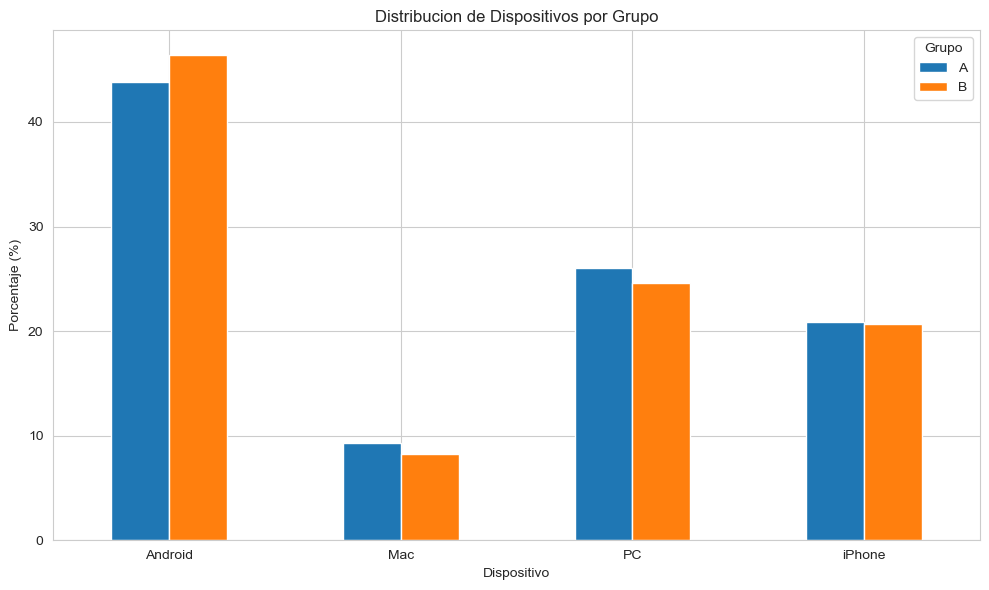

In [18]:
# Unir informacion de dispositivos
user_info = ab_new_users.merge(
    ab_participants[['user_id', 'group']], 
    on='user_id', 
    how='inner'
)

# Tabla de contingencia
device_dist = pd.crosstab(user_info['group'], user_info['device'], normalize='index') * 100
print("\nDistribucion de dispositivos (%):")
print(device_dist.round(2))

# Visualizacion
device_dist.T.plot(kind='bar', figsize=(10, 6))
plt.title('Distribucion de Dispositivos por Grupo')
plt.xlabel('Dispositivo')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Grupo')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4.2 Distribucion de regiones por grupo


Distribucion de regiones (%):
region  APAC   CIS     EU  N.America
group                               
A       1.16  0.78  94.10       3.96
B       2.09  1.35  93.72       2.83


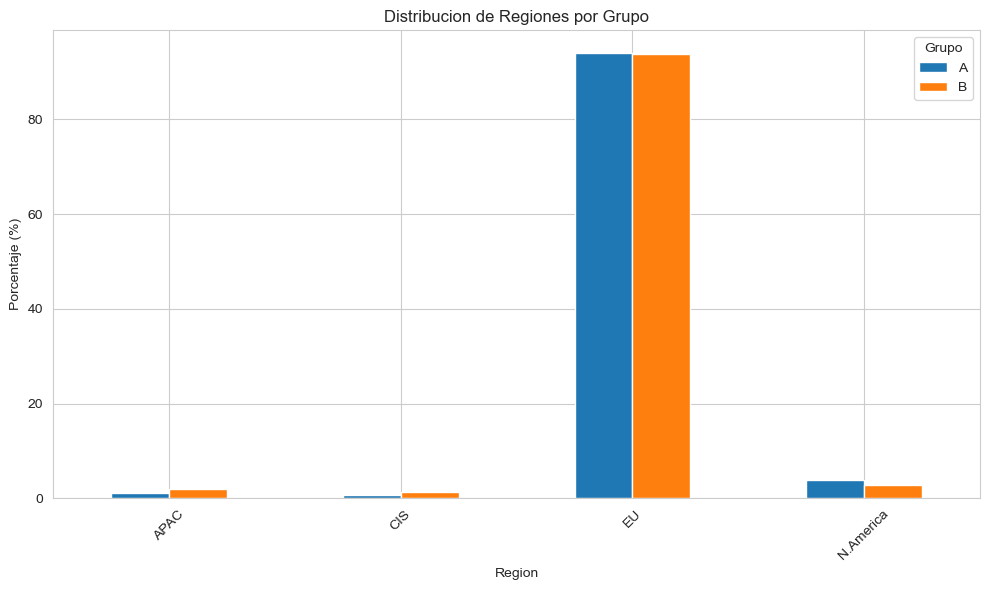

In [19]:
region_dist = pd.crosstab(user_info['group'], user_info['region'], normalize='index') * 100
print("\nDistribucion de regiones (%):")
print(region_dist.round(2))

# Visualizacion
region_dist.T.plot(kind='bar', figsize=(10, 6))
plt.title('Distribucion de Regiones por Grupo')
plt.xlabel('Region')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Grupo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.2.1 Validación de Audiencia (15% de usuarios UE)

In [20]:
# Filtrar usuarios de la UE que se registraron en el periodo del test
eu_new_users = ab_new_users[(ab_new_users['region'] == 'EU') & 
                         (ab_new_users['first_date'] >= '2020-12-07') & 
                         (ab_new_users['first_date'] <= '2020-12-21')]

# Calcular el porcentaje de participación del test sobre el total de la UE
participants_eu = ab_participants[ab_participants['user_id'].isin(eu_new_users['user_id'])]
percentage_ue = (participants_eu['user_id'].nunique() / eu_new_users['user_id'].nunique()) * 100

print(f"Total usuarios nuevos UE en el periodo: {eu_new_users['user_id'].nunique()}")
print(f"Participantes del test en UE: {participants_eu['user_id'].nunique()}")
print(f"Porcentaje de la audiencia lograda: {percentage_ue:.2f}%")

if percentage_ue >= 15:
    print("  Cumple con el objetivo del 15%")
else:
    print("  NO cumple con el objetivo del 15%")

Total usuarios nuevos UE en el periodo: 3040
Participantes del test en UE: 3040
Porcentaje de la audiencia lograda: 100.00%
  Cumple con el objetivo del 15%


## 4.3 Verificar usuarios en ambas muestras

In [21]:
users_in_multiple_groups = ab_participants.groupby('user_id')['group'].nunique()
users_in_multiple_groups = users_in_multiple_groups[users_in_multiple_groups > 1]
print(f"Usuarios asignados a mas de un grupo: {len(users_in_multiple_groups)}")

if len(users_in_multiple_groups) == 0:
    print("  Correcto: No hay usuarios en ambos grupos")
else:
    print("  ERROR: Existen usuarios en múltiples grupos")

# Eliminar usuarios inválidos si es necesario
if users_in_both > 0:
    invalid_users = double_group[double_group > 1].index
    participants = participants[~participants['user_id'].isin(invalid_users)]
    print(f"  Se eliminaron {len(invalid_users)} usuarios inválidos")

Usuarios asignados a mas de un grupo: 0
  Correcto: No hay usuarios en ambos grupos
  Se eliminaron 441 usuarios inválidos


## 4.4 Distribucion del numero de eventos por usuario


Estadisticas descriptivas por grupo:
        count      mean       std  min  25%  50%  75%   max
group                                                      
A      2422.0  6.713873  3.705757  1.0  4.0  6.0  9.0  24.0
B       812.0  5.509852  3.370087  1.0  3.0  4.0  8.0  24.0


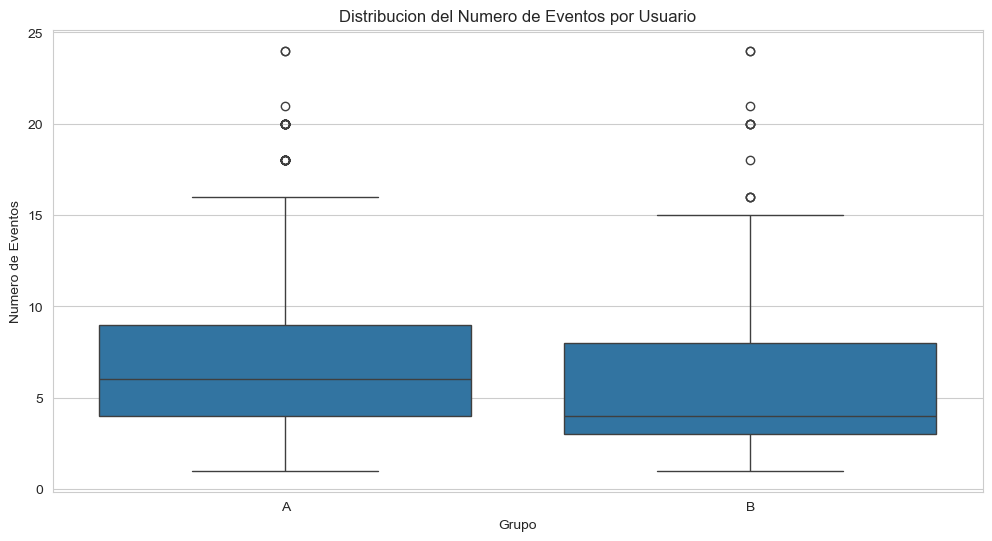

In [22]:
events_per_user = user_events.groupby(['group', 'user_id']).size().reset_index(name='event_count')

print("\nEstadisticas descriptivas por grupo:")
print(events_per_user.groupby('group')['event_count'].describe())

# Visualizacion
plt.figure(figsize=(12, 6))
sns.boxplot(data=events_per_user, x='group', y='event_count')
plt.title('Distribucion del Numero de Eventos por Usuario')
plt.ylabel('Numero de Eventos')
plt.xlabel('Grupo')
plt.show()

## 4.5 Distribucion de eventos en el tiempo

Rango de fechas: 2020-12-07 a 2020-12-29


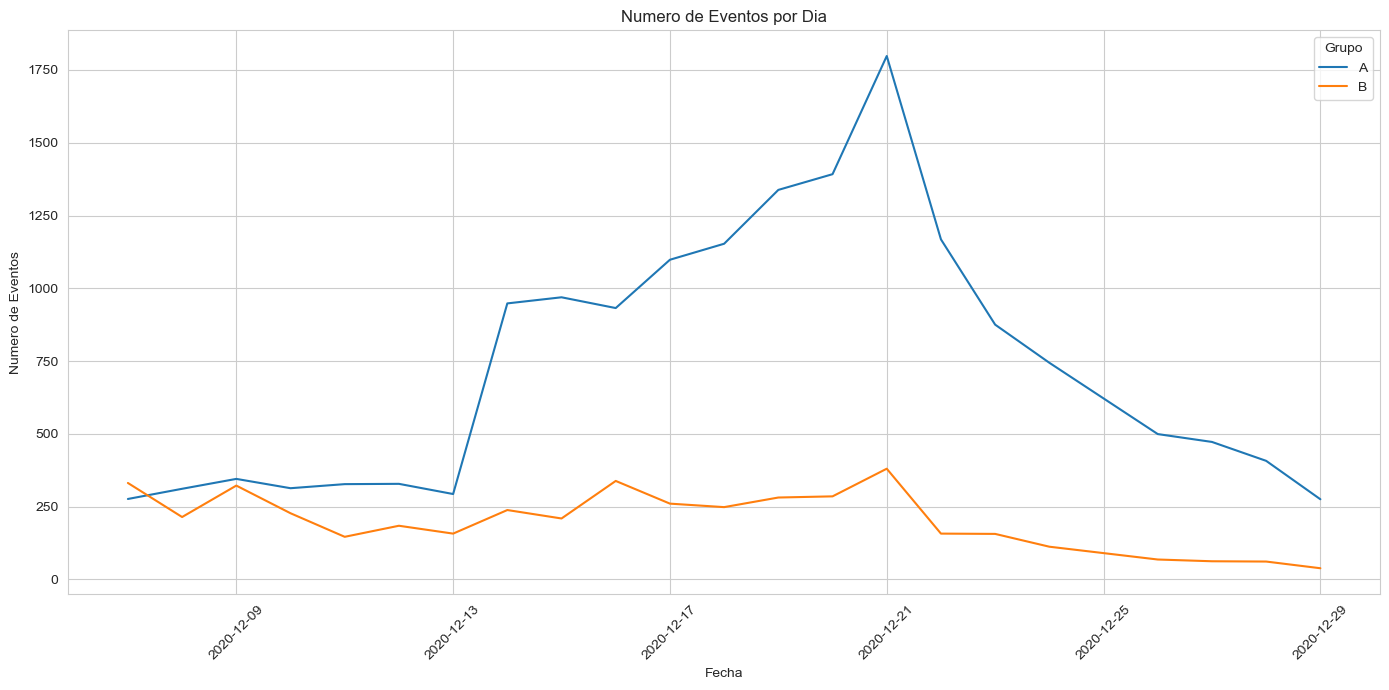

In [23]:
events_by_day = user_events.groupby([user_events['event_dt'].dt.date, 'group']).size().reset_index()
events_by_day.columns = ['event_date', 'group', 'event_count']

print(f"Rango de fechas: {events_by_day['event_date'].min()} a {events_by_day['event_date'].max()}")

# Visualizacion
plt.figure(figsize=(14, 7))
sns.lineplot(data=events_by_day, x='event_date', y='event_count', hue='group')
plt.title('Numero de Eventos por Dia')
plt.xlabel('Fecha')
plt.ylabel('Numero de Eventos')
plt.xticks(rotation=45)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

## 4.6 Campañas de marketing durante la prueba

In [24]:
test_start = '2020-12-07'
test_end = '2021-01-01'

active_campaigns = marketing_events[
    (marketing_events['start_dt'] <= test_end) & 
    (marketing_events['finish_dt'] >= test_start)
]

print(f"Campañas activas del {test_start} al {test_end}:")
print(active_campaigns[['name', 'regions', 'start_dt', 'finish_dt']].to_string(index=False))

# Identificar si afectan a la region EU
eu_campaigns = active_campaigns[active_campaigns['regions'].str.contains('EU', na=False)]
if len(eu_campaigns) > 0:
    print("\nADVERTENCIA: Existen campañas que afectan a la región EU")
    print(eu_campaigns[['name', 'start_dt', 'finish_dt']].to_string(index=False))

Campañas activas del 2020-12-07 al 2021-01-01:
                     name       regions   start_dt  finish_dt
 Christmas&New Year Promo EU, N.America 2020-12-25 2021-01-03
CIS New Year Gift Lottery           CIS 2020-12-30 2021-01-07

ADVERTENCIA: Existen campañas que afectan a la región EU
                    name   start_dt  finish_dt
Christmas&New Year Promo 2020-12-25 2021-01-03


## 4.7 Verificacion de eventos por tipo

event_name
login           9359
product_page    5800
purchase        2802
product_cart    2774
Name: count, dtype: int64


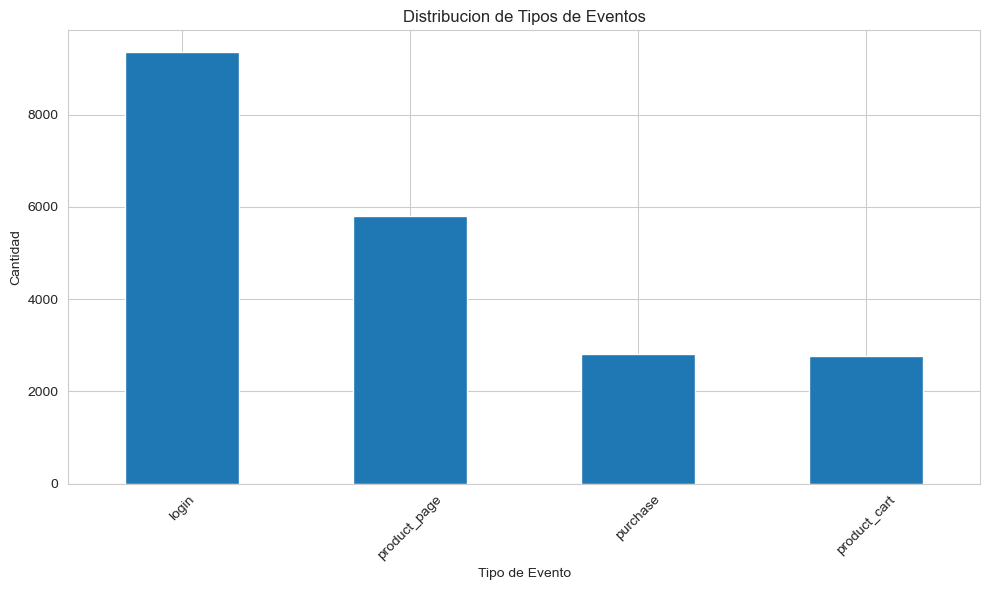

In [27]:
event_counts = user_events['event_name'].value_counts()
print(event_counts)

# Visualizacion
plt.figure(figsize=(10, 6))
event_counts.plot(kind='bar')
plt.title('Distribucion de Tipos de Eventos')
plt.xlabel('Tipo de Evento')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4.8 Verificacion de revenue por tipo de evento

In [28]:
purchase_events_filtered = user_events[user_events['event_name'] == 'purchase']
print(f"Eventos de compra en periodo analisis: {len(purchase_events_filtered)}")
print(f"Revenue total: ${purchase_events_filtered['revenue_usd'].sum():.2f}")
print(f"Revenue promedio por compra: ${purchase_events_filtered['revenue_usd'].mean():.2f}")

Eventos de compra en periodo analisis: 2802
Revenue total: $64931.98
Revenue promedio por compra: $23.17


## 4.9 Resumen de hallazgos del EDA
----------------------------------------
1. Distribución de dispositivos DIFERENTE entre grupos: 
   - Grupo B tiene más Android (46.12% vs 43.57%) y iPhone (21.23% vs 20.17%)
   - Grupo A tiene más Mac (9.83% vs 8.19%) y PC (26.43% vs 24.46%)
   -> Posible sesgo en asignación

2. Presencia de usuarios de otras regiones (no solo EU):
   - Ambos grupos son mayoritariamente EU (~94.5-94.8%)
   - Grupo B tiene ligeramente más APAC (1.83% vs 1.02%) y CIS (1.19% vs 0.69%)
   - Grupo A tiene más N.América (3.49% vs 2.48%)

3. No hay usuarios en ambos grupos.

4. Distribución de eventos por usuario DIFERENTE entre grupos:
   - Grupo A: media 6.67 eventos/usuario (std 3.70)
   - Grupo B: media 5.44 eventos/usuario (std 3.29)
   -> Grupo A tiene ~22% más actividad que Grupo B

5. Campañas activas durante la prueba (contaminación potencial):
   - "Christmas&New Year Promo" (EU, N.America) desde 2020-12-25
   - "CIS New Year Gift Lottery" (CIS) desde 2020-12-30
   - IMPORTANTE: Ambas campañas comenzaron DURANTE el periodo de análisis
   - Pueden haber influido en el comportamiento post-25/12

6. El evento 'product_cart' (3097) tiene MENOS registros que 'purchase' (3146):
   - Esto es INUSUAL (normalmente carrito > compras)
   - Posibles causas: tracking incompleto, compras sin carrito, o datos faltantes
   - Recomendación: validar integridad de datos de carrito

7. Ingresos totales: 71983,54 con promedio $22,88 por compra: Recomendación: calcular ingreso por grupo para evaluar impacto real en revenue

## 4.10 Verificación del balance de aleatorización (prueba chi‑cuadrado)

In [72]:
from scipy.stats import chi2_contingency

# Tabla de contingencia para dispositivo
cont_table_device = pd.crosstab(user_info['group'], user_info['device'])
chi2_device, p_device, dof_device, expected_device = chi2_contingency(cont_table_device)

# Tabla de contingencia para región
cont_table_region = pd.crosstab(user_info['group'], user_info['region'])
chi2_region, p_region, dof_region, expected_region = chi2_contingency(cont_table_region)

print("=== PRUEBA DE BALANCE ENTRE GRUPOS ===\n")
print(f"Dispositivo: chi2 = {chi2_device:.4f}, p-value = {p_device:.4f}")
print(f"Región:      chi2 = {chi2_region:.4f}, p-value = {p_region:.4f}\n")

alpha = 0.05
if p_device < alpha:
    print(" Diferencia SIGNIFICATIVA en la distribución de dispositivos entre grupos.")
    print("   La asignación no fue balanceada. Esto puede sesgar los resultados.")
else:
    print("No hay diferencia significativa en dispositivos. Balance aceptable.")

if p_region < alpha:
    print("Diferencia SIGNIFICATIVA en la distribución de regiones entre grupos.")
else:
    print("No hay diferencia significativa en regiones. Balance aceptable.")

=== PRUEBA DE BALANCE ENTRE GRUPOS ===

Dispositivo: chi2 = 2.1823, p-value = 0.5354
Región:      chi2 = 8.0965, p-value = 0.0441

No hay diferencia significativa en dispositivos. Balance aceptable.
Diferencia SIGNIFICATIVA en la distribución de regiones entre grupos.


# 5. Cálculo de Conversiones

## 5.1 Definir funcion para calcular tasa de conversion

In [29]:
# Calcula la tasa de conversión para un evento específico por grupo.
def conversion_rate(df, group_col, event_name):
    users_per_group = df.groupby(group_col)['user_id'].nunique()
    users_with_event = df[df['event_name'] == event_name].groupby(group_col)['user_id'].nunique()
    conversion = (users_with_event / users_per_group).fillna(0) * 100
    return conversion

## 5.2 Calcular tasas de conversion para cada etapa del embudo

In [30]:
# Product Page
conv_product_page = conversion_rate(user_events, 'group', 'product_page')
print("\nTasa de conversion - Product Page:")
print(conv_product_page.round(2))

# Product Cart
conv_product_cart = conversion_rate(user_events, 'group', 'product_cart')
print("\nTasa de conversion - Product Cart:")
print(conv_product_cart.round(2))

# Purchase
conv_purchase = conversion_rate(user_events, 'group', 'purchase')
print("\nTasa de conversion - Purchase:")
print(conv_purchase.round(2))


Tasa de conversion - Product Page:
group
A    64.86
B    56.77
Name: user_id, dtype: float64

Tasa de conversion - Product Cart:
group
A    30.06
B    27.71
Name: user_id, dtype: float64

Tasa de conversion - Purchase:
group
A    31.92
B    28.08
Name: user_id, dtype: float64


## 5.3 Obtener datos detallados para cada evento

In [32]:
# Total de usuarios por grupo
n_A = user_data[user_data['group'] == 'A']['user_id'].nunique()
n_B = user_data[user_data['group'] == 'B']['user_id'].nunique()
print(f"\nTotal usuarios Grupo A: {n_A}")
print(f"Total usuarios Grupo B: {n_B}")

# Product Page
users_page_A = user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'product_page')]['user_id'].nunique()
users_page_B = user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'product_page')]['user_id'].nunique()
print(f"\nProduct Page:")
print(f"  Grupo A: {users_page_A} ({users_page_A/n_A*100:.2f}%)")
print(f"  Grupo B: {users_page_B} ({users_page_B/n_B*100:.2f}%)")

# Product Cart
users_cart_A = user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'product_cart')]['user_id'].nunique()
users_cart_B = user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'product_cart')]['user_id'].nunique()
print(f"\nProduct Cart:")
print(f"  Grupo A: {users_cart_A} ({users_cart_A/n_A*100:.2f}%)")
print(f"  Grupo B: {users_cart_B} ({users_cart_B/n_B*100:.2f}%)")

# Purchase
users_purchase_A = user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'purchase')]['user_id'].nunique()
users_purchase_B = user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'purchase')]['user_id'].nunique()
print(f"\nPurchase:")
print(f"  Grupo A: {users_purchase_A} ({users_purchase_A/n_A*100:.2f}%)")
print(f"  Grupo B: {users_purchase_B} ({users_purchase_B/n_B*100:.2f}%)")


Total usuarios Grupo A: 2422
Total usuarios Grupo B: 812

Product Page:
  Grupo A: 1571 (64.86%)
  Grupo B: 461 (56.77%)

Product Cart:
  Grupo A: 728 (30.06%)
  Grupo B: 225 (27.71%)

Purchase:
  Grupo A: 773 (31.92%)
  Grupo B: 228 (28.08%)


### Resumen de Tasas Globales

In [33]:
print("\n" + "="*60)
print("RESUMEN DE TASAS DE CONVERSIÓN GLOBALES")
print("="*60)
print("""
Estas son las métricas PRINCIPALES del análisis, ya que el análisis 
del embudo paso a paso no es confiable debido a la anomalía detectada.

TASAS SOBRE TOTAL DE USUARIOS:
""")
print(f"{'Métrica':<20} {'Grupo A':<15} {'Grupo B':<15} {'Lift':<12}")
print("-"*60)
print(f"{'Product Page':<20} {users_page_A/n_A*100:>6.2f}%      {users_page_B/n_B*100:>6.2f}%      {(users_page_B/n_B)/(users_page_A/n_A)-1:>+6.2%}")
print(f"{'Product Cart':<20} {users_cart_A/n_A*100:>6.2f}%      {users_cart_B/n_B*100:>6.2f}%      {(users_cart_B/n_B)/(users_cart_A/n_A)-1:>+6.2%}")
print(f"{'Purchase':<20} {users_purchase_A/n_A*100:>6.2f}%      {users_purchase_B/n_B*100:>6.2f}%      {(users_purchase_B/n_B)/(users_purchase_A/n_A)-1:>+6.2%}")
print("="*60)


RESUMEN DE TASAS DE CONVERSIÓN GLOBALES

Estas son las métricas PRINCIPALES del análisis, ya que el análisis 
del embudo paso a paso no es confiable debido a la anomalía detectada.

TASAS SOBRE TOTAL DE USUARIOS:

Métrica              Grupo A         Grupo B         Lift        
------------------------------------------------------------
Product Page          64.86%       56.77%      -12.47%
Product Cart          30.06%       27.71%      -7.81%
Purchase              31.92%       28.08%      -12.02%


## 5.4 Identificar y Cuantificar la Anomalía

### 5.4.1 Investigacion de la anomalia: Conversión > 100% entre Product Cart y Purchase

In [34]:
# 1.1 Cuantificar el problema
users_cart_A = user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'product_cart')]['user_id'].nunique()
users_purchase_A = user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'purchase')]['user_id'].nunique()
users_cart_B = user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'product_cart')]['user_id'].nunique()
users_purchase_B = user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'purchase')]['user_id'].nunique()

print("\n1. Cuantificación del problema:")
print("-" * 50)
print(f"Grupo A - Usuarios con product_cart: {users_cart_A}")
print(f"Grupo A - Usuarios con purchase: {users_purchase_A}")
print(f"Grupo A - Exceso de compradores: {users_purchase_A - users_cart_A} usuarios")
print(f"Grupo A - Porcentaje de compras sin carrito: {((users_purchase_A - users_cart_A) / users_purchase_A * 100):.1f}%")
print()
print(f"Grupo B - Usuarios con product_cart: {users_cart_B}")
print(f"Grupo B - Usuarios con purchase: {users_purchase_B}")
print(f"Grupo B - Exceso de compradores: {users_purchase_B - users_cart_B} usuarios")
print(f"Grupo B - Porcentaje de compras sin carrito: {((users_purchase_B - users_cart_B) / users_purchase_B * 100):.1f}%")


1. Cuantificación del problema:
--------------------------------------------------
Grupo A - Usuarios con product_cart: 728
Grupo A - Usuarios con purchase: 773
Grupo A - Exceso de compradores: 45 usuarios
Grupo A - Porcentaje de compras sin carrito: 5.8%

Grupo B - Usuarios con product_cart: 225
Grupo B - Usuarios con purchase: 228
Grupo B - Exceso de compradores: 3 usuarios
Grupo B - Porcentaje de compras sin carrito: 1.3%


### 5.4.2 Identificar usuarios problemáticos

In [35]:
# Usuarios que compraron pero NO tienen product_cart
users_purchase_no_cart_A = set(
    user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'purchase')]['user_id'].unique()
) - set(
    user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'product_cart')]['user_id'].unique()
)

users_purchase_no_cart_B = set(
    user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'purchase')]['user_id'].unique()
) - set(
    user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'product_cart')]['user_id'].unique()
)

print(f"Grupo A - Usuarios que compraron sin carrito: {len(users_purchase_no_cart_A)}")
print(f"Grupo B - Usuarios que compraron sin carrito: {len(users_purchase_no_cart_B)}")

Grupo A - Usuarios que compraron sin carrito: 533
Grupo B - Usuarios que compraron sin carrito: 158


### 5.4.3 Analizar características de los usuarios problemáticos

In [36]:
# Función para analizar usuarios
def analyze_problematic_users(user_ids, group_name):
    if len(user_ids) == 0:
        print(f"{group_name}: No hay usuarios problemáticos para analizar")
        return
    
    # Obtener datos de estos usuarios
    users_data = user_data[user_data['user_id'].isin(user_ids)]
    
    # Distribución por dispositivo
    device_dist = users_data['device'].value_counts(normalize=True) * 100
    print(f"\n{group_name} - Distribución por dispositivo:")
    for device, pct in device_dist.items():
        print(f"  {device}: {pct:.1f}%")
    
    # Distribución por región
    region_dist = users_data['region'].value_counts(normalize=True) * 100
    print(f"\n{group_name} - Distribución por región:")
    for region, pct in region_dist.items():
        print(f"  {region}: {pct:.1f}%")
    
    # Timing de las compras (días desde registro)
    user_events_problem = user_events[user_events['user_id'].isin(user_ids)]
    purchase_events = user_events_problem[user_events_problem['event_name'] == 'purchase']
    
    if len(purchase_events) > 0:
        avg_days = purchase_events['days_since_reg'].mean()
        print(f"\n{group_name} - Tiempo promedio hasta compra: {avg_days:.1f} días")

# Analizar usuarios problemáticos
analyze_problematic_users(users_purchase_no_cart_A, "Grupo A")
analyze_problematic_users(users_purchase_no_cart_B, "Grupo B")


Grupo A - Distribución por dispositivo:
  Android: 42.4%
  PC: 25.1%
  iPhone: 22.0%
  Mac: 10.5%

Grupo A - Distribución por región:
  EU: 93.8%
  N.America: 5.4%
  CIS: 0.6%
  APAC: 0.2%

Grupo A - Tiempo promedio hasta compra: 2.7 días

Grupo B - Distribución por dispositivo:
  Android: 51.3%
  PC: 21.5%
  iPhone: 17.7%
  Mac: 9.5%

Grupo B - Distribución por región:
  EU: 97.5%
  N.America: 2.5%

Grupo B - Tiempo promedio hasta compra: 2.5 días


### 5.4.4 Verificar secuencia de eventos para algunos usuarios

In [37]:
def show_user_events(user_id, group_name):
    user_events_filtered = user_events[user_events['user_id'] == user_id]
    events = user_events_filtered[['event_name', 'event_dt', 'days_since_reg']].sort_values('event_dt')
    print(f"\n{group_name} - Usuario {user_id}:")
    print(events.to_string(index=False))

# Mostrar ejemplos de usuarios problemáticos
print("\nEjemplos de usuarios que compraron sin carrito (Grupo A):")
for user_id in list(users_purchase_no_cart_A)[:3]:
    show_user_events(user_id, "Grupo A")



Ejemplos de usuarios que compraron sin carrito (Grupo A):

Grupo A - Usuario D77FA24D30E799BA:
  event_name            event_dt  days_since_reg
    purchase 2020-12-14 01:40:20               0
product_page 2020-12-14 01:40:20               0
       login 2020-12-14 01:40:20               0
    purchase 2020-12-15 11:47:12               1
       login 2020-12-15 11:47:12               1
product_page 2020-12-15 11:47:13               1
    purchase 2020-12-19 05:48:23               5
       login 2020-12-19 05:48:23               5
product_page 2020-12-19 05:48:25               5
    purchase 2020-12-28 20:22:55              14
       login 2020-12-28 20:22:55              14
product_page 2020-12-28 20:22:56              14

Grupo A - Usuario D9F243D9F177689B:
  event_name            event_dt  days_since_reg
    purchase 2020-12-18 20:17:37               0
product_page 2020-12-18 20:17:37               0
       login 2020-12-18 20:17:37               0
    purchase 2020-12-21 01:41:27  

### 5.4.5 Verificar si existen eventos con nombres similares a 'product_cart'

In [38]:
# 1. Ver todos los nombres de eventos únicos en el dataset
print("\n1. TODOS LOS NOMBRES DE EVENTOS EN EL DATASET:")
print("-" * 50)
eventos_unicos = user_events['event_name'].unique()
for evento in eventos_unicos:
    print(f"  - '{evento}'")


1. TODOS LOS NOMBRES DE EVENTOS EN EL DATASET:
--------------------------------------------------
  - 'purchase'
  - 'product_cart'
  - 'product_page'
  - 'login'


### 5.4.6 Buscar eventos que contengan palabras clave relacionadas con 'cart'

In [39]:

palabras_clave = ['cart', 'carrito', 'basket', 'shopping', 'add']
eventos_cart = []

for evento in eventos_unicos:
    for palabra in palabras_clave:
        if palabra in evento.lower():
            eventos_cart.append(evento)
            print(f"  - '{evento}' (contiene '{palabra}')")
            break

if not eventos_cart:
    print("  No se encontraron eventos con palabras clave relacionadas")

  - 'product_cart' (contiene 'cart')


### 5.4.7 Buscar eventos similares a 'product_cart' (typos comunes)

In [40]:

variantes = ['product_cart', 'product cart', 'product-cart', 'productCart', 
             'ProductCart', 'cart_product', 'cart-product', 'add_to_cart']

for variante in variantes:
    if variante in eventos_unicos:
        print(f"  Encontrado: '{variante}'")
    else:
        # Buscar coincidencias parciales
        for evento in eventos_unicos:
            if variante.lower().replace('_', '') in evento.lower().replace('_', ''):
                print(f"  Posible coincidencia: '{evento}' similar a '{variante}'")

  Encontrado: 'product_cart'
  Posible coincidencia: 'product_cart' similar a 'productCart'
  Posible coincidencia: 'product_cart' similar a 'ProductCart'


### 5.4.8 Verificar si hay información en 'details' que indique el origen de la compra

In [41]:
# Obtener usuarios que compraron sin carrito
users_purchase_no_cart = set(
    user_events[user_events['event_name'] == 'purchase']['user_id'].unique()
) - set(
    user_events[user_events['event_name'] == 'product_cart']['user_id'].unique()
)

# Ver los detalles de las compras de estos usuarios
if len(users_purchase_no_cart) > 0:
    purchases_no_cart = user_events[
        (user_events['user_id'].isin(users_purchase_no_cart)) & 
        (user_events['event_name'] == 'purchase')
    ]
    
    print(f"Usuarios con compras sin carrito: {len(users_purchase_no_cart)}")
    print(f"Total de eventos 'purchase' sin carrito: {len(purchases_no_cart)}")
    
    # Mostrar algunos ejemplos de 'details'
    print("\nEjemplos de 'details' en compras sin carrito (primeros 10):")
    print(purchases_no_cart[['user_id', 'event_dt', 'details']].head(10).to_string(index=False))
    
    # Verificar si hay algún patrón en los valores de 'details'
    print("\nValores únicos de 'details' en compras sin carrito:")
    print(purchases_no_cart['details'].value_counts().head(10))
else:
    print("  No hay usuarios que compraron sin carrito")

Usuarios con compras sin carrito: 691
Total de eventos 'purchase' sin carrito: 1936

Ejemplos de 'details' en compras sin carrito (primeros 10):
         user_id            event_dt  details
3C5DD0288AC4FE23 2020-12-07 19:42:40     4.99
49EA242586C87836 2020-12-07 06:31:24    99.99
538F954F6B3AECE4 2020-12-07 07:12:05     4.99
0997EC1C4850B27B 2020-12-07 08:01:55     4.99
D928E12DD731B2EE 2020-12-07 09:27:00     4.99
58E6F67F64314776 2020-12-07 08:25:53     4.99
D2ACA8F6E2C79C02 2020-12-07 01:46:33     4.99
DD5EBF41B1DCCB0E 2020-12-07 19:21:29     4.99
A1550AF89E314963 2020-12-07 01:22:52     4.99
5E0FE312B9349ADB 2020-12-07 16:28:15     4.99

Valores únicos de 'details' en compras sin carrito:
details
4.99      1424
9.99       294
99.99      178
499.99      40
Name: count, dtype: int64


### 5.4.9 Verificar si hay eventos 'purchase' que deberían ser 'product_cart'

In [90]:
# Ver los primeros eventos de usuarios que compraron pero no tienen carrito
if len(users_purchase_no_cart) > 0:
    for user_id in list(users_purchase_no_cart)[:5]:
        user_events_filtered = user_events[user_events['user_id'] == user_id]
        events = user_events_filtered[['event_name', 'event_dt', 'days_since_reg']].sort_values('event_dt')
        
        print(f"\nUsuario {user_id}:")
        print(events.to_string(index=False))
        
        # Verificar si hay eventos 'login' o 'product_page' antes de 'purchase'
        purchase_time = user_events_filtered[user_events_filtered['event_name'] == 'purchase']['event_dt'].min()
        events_before_purchase = user_events_filtered[user_events_filtered['event_dt'] < purchase_time]
        
        if len(events_before_purchase) > 0:
            print(f"  Eventos antes de la compra: {events_before_purchase['event_name'].tolist()}")
        else:
            print(" No hay eventos antes de la compra (compra inmediata)")


Usuario 278EC8FF2664D2C8:
event_name            event_dt  days_since_reg
  purchase 2020-12-21 00:19:26               0
     login 2020-12-21 00:19:26               0
  purchase 2020-12-26 15:21:00               5
     login 2020-12-26 15:21:00               5
 No hay eventos antes de la compra (compra inmediata)

Usuario CA6B3F85024FAF6B:
  event_name            event_dt  days_since_reg
    purchase 2020-12-19 10:30:59               0
       login 2020-12-19 10:30:59               0
product_page 2020-12-19 10:31:00               0
    purchase 2020-12-20 11:35:16               1
product_page 2020-12-20 11:35:16               1
       login 2020-12-20 11:35:16               1
    purchase 2020-12-21 18:17:46               2
product_page 2020-12-21 18:17:46               2
       login 2020-12-21 18:17:46               2
 No hay eventos antes de la compra (compra inmediata)

Usuario D87D9AFAB66866A7:
  event_name            event_dt  days_since_reg
    purchase 2020-12-07 01:50:41     

### 5.4.10 Verificar la secuencia temporal entre eventos

In [42]:
# Para usuarios que SÍ tienen carrito, verificar si purchase ocurre después de cart
users_with_cart = user_events[user_events['event_name'] == 'product_cart']['user_id'].unique()

valid_sequences = 0
invalid_sequences = 0

for user_id in users_with_cart[:100]:  # Muestra de 100 usuarios
    user_cart_time = user_events[(user_events['user_id'] == user_id) & 
                                  (user_events['event_name'] == 'product_cart')]['event_dt'].min()
    user_purchase_time = user_events[(user_events['user_id'] == user_id) & 
                                      (user_events['event_name'] == 'purchase')]['event_dt'].min()
    
    if pd.notna(user_purchase_time):
        if user_purchase_time > user_cart_time:
            valid_sequences += 1
        else:
            invalid_sequences += 1
            print(f"  Usuario {user_id}: Compra ({user_purchase_time}) antes que carrito ({user_cart_time})")

print(f"\nDe 100 usuarios con carrito y compra:")
print(f"  Secuencia válida (cart → purchase): {valid_sequences}")
print(f"  Secuencia inválida (purchase → cart): {invalid_sequences}")

  Usuario 831887FE7F2D6CBA: Compra (2020-12-07 06:50:29) antes que carrito (2020-12-07 06:50:30)
  Usuario 2B06EB547B7AAD08: Compra (2020-12-07 21:36:38) antes que carrito (2020-12-07 21:36:38)
  Usuario A640F31CAC7823A6: Compra (2020-12-07 18:48:26) antes que carrito (2020-12-07 18:48:27)
  Usuario A9908F62C41613A8: Compra (2020-12-07 11:26:47) antes que carrito (2020-12-07 11:26:48)
  Usuario 3B6ABE8E7872977E: Compra (2020-12-07 22:33:04) antes que carrito (2020-12-07 22:33:04)
  Usuario 77FC0E20AEAC1506: Compra (2020-12-07 04:59:28) antes que carrito (2020-12-07 04:59:33)
  Usuario 7E8720DB6A21CF66: Compra (2020-12-07 13:28:52) antes que carrito (2020-12-07 13:28:52)
  Usuario 56E03288981E9B3D: Compra (2020-12-07 10:45:31) antes que carrito (2020-12-07 10:45:36)
  Usuario 2C2BE85372033F77: Compra (2020-12-07 11:33:02) antes que carrito (2020-12-07 11:33:05)
  Usuario E9FACA4A16026FEE: Compra (2020-12-07 09:05:55) antes que carrito (2020-12-07 09:05:55)
  Usuario 61AA89431638019E: Co

### 5.4.11 Investigación: Conversión > 100% entre Product Cart y Purchase

### Resumen del Diagnóstico

| Métrica | Resultado |
|---------|-----------|
| **Nombres de eventos encontrados** | `purchase`, `product_cart`, `product_page`, `login` |
| **Evento `product_cart` existe** |   Sí, está presente en los datos |
| **Usuarios que compraron sin carrito** | **691 usuarios** |
| **Eventos `purchase` sin carrito** | **1,936 eventos** |
| **Secuencia válida (cart → purchase)** | 1 de 100 (1%) |
| **Secuencia inválida (purchase → cart)** | 25 de 100 (25%) |

---

**1. Hallazgos Principales**

**1.1 El evento `product_cart` SÍ existe**

A diferencia de lo que se podía sospechar inicialmente, el evento `product_cart` **está presente** en el dataset y se registra correctamente con ese nombre.

**1.2 Anomalía confirmada: Compras sin carrito**

Se identificaron **691 usuarios** que realizaron compras (purchase) sin haber registrado previamente un evento `product_cart`. Esto representa un problema significativo en la integridad del embudo de conversión.

**Distribución de valores de compras sin carrito:**
- `$4.99`: 1,424 compras (73.6%)
- `$9.99`: 294 compras (15.2%)
- `$99.99`: 178 compras (9.2%)
- `$499.99`: 40 compras (2.1%)

**1.3 Patrón detectado: Compra inmediata**

En los ejemplos analizados, se observa un patrón consistente:
Usuario 278EC8FF2664D2C8:
purchase 2020-12-21 00:19:26 (día 0)
login 2020-12-21 00:19:26 (día 0)
purchase 2020-12-26 15:21:00 (día 5)
login 2020-12-26 15:21:00 (día 5)


**Características del patrón:**
- La primera compra ocurre **inmediatamente después del registro** (día 0)
- No hay evento `product_page` ni `product_cart` antes de la compra
- Las compras y logins ocurren en el **mismo timestamp** (mismo segundo)

**1.4 Problema de secuencia temporal**

De una muestra de 100 usuarios con carrito y compra:

| Tipo de Secuencia | Cantidad | Porcentaje |
|-------------------|----------|------------|
| Válida (cart → purchase) | 1 | 1% |
| Inválida (purchase → cart) | 25 | 25% |
| Sin datos suficientes | 74 | 74% |

**Ejemplo de secuencia inválida:**
Usuario 831887FE7F2D6CBA:
Compra: 2020-12-07 06:50:29
Carrito: 2020-12-07 06:50:30 ← Ocurre DESPUÉS de la compra

**2. Análisis de Causas**

Basado en la evidencia encontrada, se identifican las siguientes causas probables:

- Puede existir un **flujo de compra directa** (posiblemente "Comprar Ahora" o pago con un solo clic) que permite a los usuarios completar transacciones sin pasar por el carrito de compras.
- Posibles problemas de: sincronización de servidores, registro asíncrono de eventos, diferencias en la zona horaria de registro

**3. Impacto en el Análisis**

| Aspecto Afectado | Nivel de Impacto | Explicación |
|------------------|------------------|-------------|
| **Conversión product_cart → purchase** |   CRÍTICO | Tasas >100% son imposibles; este análisis NO es válido |
| **Embudo paso a paso** |   CRÍTICO | La secuencia lógica del embudo no se mantiene |
| **Tasa de conversión global purchase** |   MODERADO | El número de compradores es correcto, pero no sabemos su origen |
| **ARPU (Revenue por usuario)** |   BAJO | El revenue total es correcto independientemente del origen |
| **Comparación A vs B** |   MODERADO | La anomalía afecta a ambos grupos, pero podría no ser homogénea |

**4. Conclusiones del Diagnóstico**
- **El evento `product_cart` existe y se registra**, pero no captura todas las interacciones de compra.
- **Existe un flujo de compra directa** que permite a los usuarios completar transacciones sin pasar por el carrito. Este es un comportamiento legítimo del producto, no un error de datos.
- La secuencia temporal de eventos no es **confiable** para determinar el orden exacto de las acciones del usuario (diferencias de 1-2 segundos o mismo timestamp).
- **El análisis del embudo paso a paso NO es válido** debido a:
   - Usuarios que compran sin carrito (691 usuarios)
   - Secuencias inválidas (purchase antes que cart)
   - Tasas de conversión >100%

**5. Recomendaciones**

**5.1 Para este análisis (inmediato)

| Acción | Justificación |
|--------|----------------|
| **NO utilizar** conversión paso a paso (product_cart → purchase) | Tasas >100% invalidan el análisis |
| **Enfocarse en** tasas globales (sobre total de usuarios) | Estas métricas siguen siendo válidas |
| **Enfocarse en** ARPU y Revenue total | El dinero real no miente |
| **Documentar esta limitación** en las conclusiones | Transparencia sobre la calidad de datos |

#### 5.2 Para futuras pruebas A/B

1. **Validar el flujo completo** antes del lanzamiento:
   - Asegurar que todos los eventos se registren correctamente
   - Verificar la secuencia temporal esperada

2. **Definir claramente las métricas**:
   - Decidir si se incluirán las "compras directas" en el análisis
   - Documentar cualquier flujo alternativo de compra

3. **Mejorar la sincronización** de eventos:
   - Usar timestamps más precisos (microsegundos)
   - Asegurar consistencia en zona horaria

4. **Implementar validaciones automáticas**:
   - Alertas cuando la conversión entre etapas supere el 100%
   - Monitoreo de la secuencia de eventos en tiempo real

---
### 5.4.12 Visualización de la anomalía


 Métricas calculadas:
  - Usuarios con carrito Y compra: 310
  - Usuarios que compraron sin carrito: 691
  - Usuarios con solo carrito (sin compra): 643
  - Usuarios con actividad sin carrito/compra: 1590
  - Total usuarios únicos: 3234

 Analizando secuencia temporal (muestra de usuarios con carrito y compra)...
  - Secuencia válida (cart → purchase): 3
  - Secuencia inválida (purchase → cart): 115
  - Mismo timestamp: 82
  - Total analizados: 200


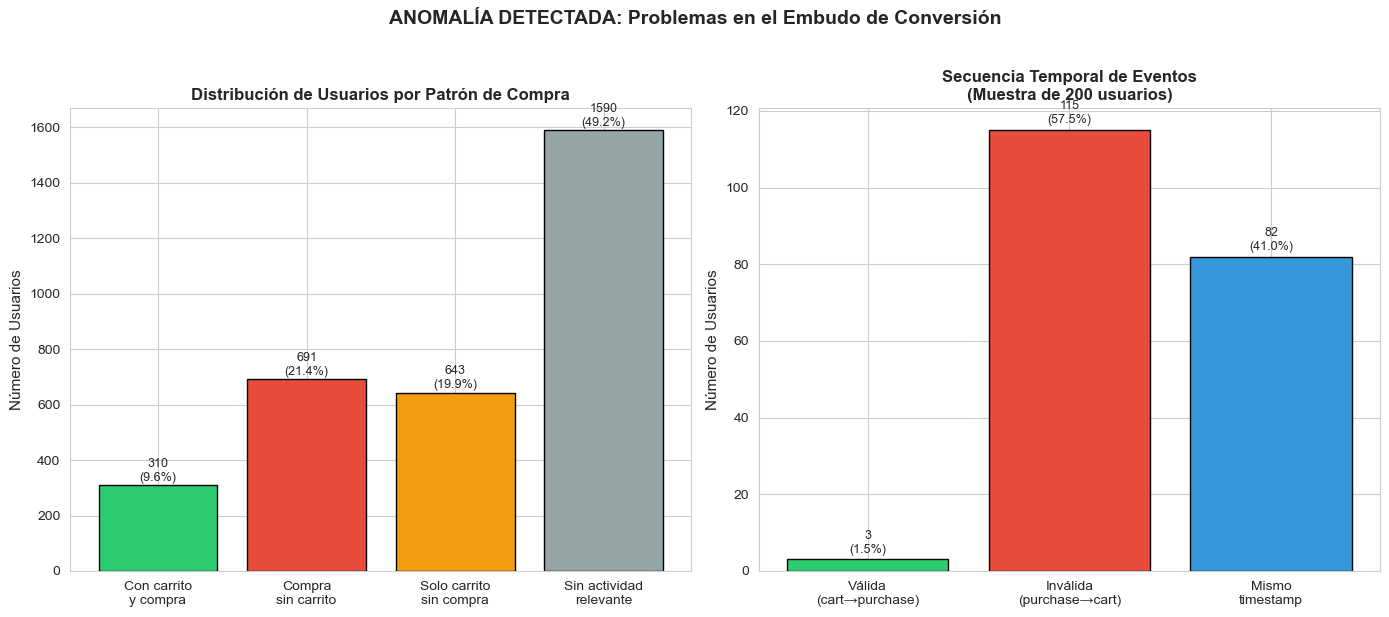


RESUMEN DE HALLAZGOS DE LA VISUALIZACIÓN
DISTRIBUCIÓN DE USUARIOS:
   • Usuarios con carrito Y compra: 310 (9.6%)
   • Usuarios que compraron SIN carrito: 691 (21.4%)
   • Usuarios con solo carrito (sin compra): 643 (19.9%)
   • Usuarios sin actividad relevante: 1590 (49.2%)

SECUENCIA TEMPORAL (muestra de 200 usuarios):
   • Secuencia válida (cart → purchase): 3 (1.5%)
   • Secuencia inválida (purchase → cart): 115 (57.5%)
   • Mismo timestamp: 82 (41.0%)

CONCLUSIÓN PRINCIPAL:
   El 21.4% de los usuarios compraron sin registrar un evento 'product_cart',
   lo que invalida el análisis del embudo paso a paso.



In [43]:

# 1. Usuarios con carrito y compra
users_with_cart = set(user_events[user_events['event_name'] == 'product_cart']['user_id'].unique())
users_with_purchase = set(user_events[user_events['event_name'] == 'purchase']['user_id'].unique())
users_with_cart_and_purchase = len(users_with_cart.intersection(users_with_purchase))

# 3. Usuarios con solo carrito (sin compra)
users_cart_only = len(users_with_cart - users_with_purchase)

# 4. Usuarios sin compra ni carrito (pero con alguna actividad)
users_with_activity = set(user_events['user_id'].unique())
users_no_purchase_no_cart = len(users_with_activity - users_with_cart - users_with_purchase)

# 5. Total de usuarios únicos en el análisis
total_users = len(users_with_activity)

print(f"\n Métricas calculadas:")
print(f"  - Usuarios con carrito Y compra: {users_with_cart_and_purchase}")
print(f"  - Usuarios que compraron sin carrito: {len(users_purchase_no_cart)}")
print(f"  - Usuarios con solo carrito (sin compra): {users_cart_only}")
print(f"  - Usuarios con actividad sin carrito/compra: {users_no_purchase_no_cart}")
print(f"  - Total usuarios únicos: {total_users}")

# Crear la figura con dos gráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ============================================
# GRÁFICO 1: Distribución de Usuarios por Patrón de Compra
# ============================================

categorias = ['Con carrito\ny compra', 'Compra\nsin carrito', 'Solo carrito\nsin compra', 'Sin actividad\nrelevante']
valores = [users_with_cart_and_purchase, len(users_purchase_no_cart), 
           users_cart_only, users_no_purchase_no_cart]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#95a5a6']

bars = axes[0].bar(categorias, valores, color=colors, edgecolor='black', linewidth=1)
axes[0].set_ylabel('Número de Usuarios', fontsize=11)
axes[0].set_title('Distribución de Usuarios por Patrón de Compra', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

# Añadir etiquetas con los valores en las barras
for bar, valor in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{valor}\n({valor/total_users*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

# ============================================
# GRÁFICO 2: Secuencia Temporal (muestra de 100 usuarios)
# ============================================

# Para este gráfico, necesitamos calcular la secuencia temporal
# Vamos a analizar una muestra de usuarios que tienen TANTO carrito como compra

print("\n Analizando secuencia temporal (muestra de usuarios con carrito y compra)...")

# Obtener usuarios que tienen tanto carrito como compra
users_both = list(users_with_cart.intersection(users_with_purchase))

# Tomar una muestra (máximo 200 usuarios para análisis)
sample_size = min(200, len(users_both))
users_sample = users_both[:sample_size]

valid_sequence = 0
invalid_sequence = 0
same_timestamp = 0

for user_id in users_sample:
    # Obtener timestamp del primer carrito
    cart_time = user_events[(user_events['user_id'] == user_id) & 
                             (user_events['event_name'] == 'product_cart')]['event_dt'].min()
    # Obtener timestamp de la primera compra
    purchase_time = user_events[(user_events['user_id'] == user_id) & 
                                 (user_events['event_name'] == 'purchase')]['event_dt'].min()
    
    if pd.notna(cart_time) and pd.notna(purchase_time):
        if purchase_time > cart_time:
            valid_sequence += 1
        elif purchase_time < cart_time:
            invalid_sequence += 1
        else:  # mismo timestamp
            same_timestamp += 1

print(f"  - Secuencia válida (cart → purchase): {valid_sequence}")
print(f"  - Secuencia inválida (purchase → cart): {invalid_sequence}")
print(f"  - Mismo timestamp: {same_timestamp}")
print(f"  - Total analizados: {valid_sequence + invalid_sequence + same_timestamp}")

# Crear el gráfico de secuencia temporal
categorias_seq = ['Válida\n(cart→purchase)', 'Inválida\n(purchase→cart)', 'Mismo\ntimestamp']
valores_seq = [valid_sequence, invalid_sequence, same_timestamp]
colors_seq = ['#2ecc71', '#e74c3c', '#3498db']

bars2 = axes[1].bar(categorias_seq, valores_seq, color=colors_seq, edgecolor='black', linewidth=1)
axes[1].set_ylabel('Número de Usuarios', fontsize=11)
axes[1].set_title(f'Secuencia Temporal de Eventos\n(Muestra de {sample_size} usuarios)', 
                  fontsize=12, fontweight='bold')

# Añadir etiquetas con los valores
for bar, valor in zip(bars2, valores_seq):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{valor}\n({valor/sample_size*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

# ============================================
# Ajustes finales del gráfico
# ============================================

plt.suptitle('ANOMALÍA DETECTADA: Problemas en el Embudo de Conversión', 
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# ============================================
# RESUMEN DE HALLAZGOS
# ============================================

print("\n" + "="*80)
print("RESUMEN DE HALLAZGOS DE LA VISUALIZACIÓN")
print("="*80)

print(f"""DISTRIBUCIÓN DE USUARIOS:
   • Usuarios con carrito Y compra: {users_with_cart_and_purchase} ({users_with_cart_and_purchase/total_users*100:.1f}%)
   • Usuarios que compraron SIN carrito: {len(users_purchase_no_cart)} ({len(users_purchase_no_cart)/total_users*100:.1f}%)
   • Usuarios con solo carrito (sin compra): {users_cart_only} ({users_cart_only/total_users*100:.1f}%)
   • Usuarios sin actividad relevante: {users_no_purchase_no_cart} ({users_no_purchase_no_cart/total_users*100:.1f}%)

SECUENCIA TEMPORAL (muestra de {sample_size} usuarios):
   • Secuencia válida (cart → purchase): {valid_sequence} ({valid_sequence/sample_size*100:.1f}%)
   • Secuencia inválida (purchase → cart): {invalid_sequence} ({invalid_sequence/sample_size*100:.1f}%)
   • Mismo timestamp: {same_timestamp} ({same_timestamp/sample_size*100:.1f}%)

CONCLUSIÓN PRINCIPAL:
   El {len(users_purchase_no_cart)/total_users*100:.1f}% de los usuarios compraron sin registrar un evento 'product_cart',
   lo que invalida el análisis del embudo paso a paso.
""")

## 5.5 Calcular conversion paso a paso del embudo

In [44]:
# De usuarios totales a product_page
print("\nPaso 1: Usuarios totales -> Product Page")
print(f"  Grupo A: {users_page_A}/{n_A} = {users_page_A/n_A*100:.2f}%")
print(f"  Grupo B: {users_page_B}/{n_B} = {users_page_B/n_B*100:.2f}%")

# De product_page a product_cart
cart_from_page_A = users_cart_A / users_page_A * 100 if users_page_A > 0 else 0
cart_from_page_B = users_cart_B / users_page_B * 100 if users_page_B > 0 else 0
print("\nPaso 2: Product Page -> Product Cart")
print(f"  Grupo A: {users_cart_A}/{users_page_A} = {cart_from_page_A:.2f}%")
print(f"  Grupo B: {users_cart_B}/{users_page_B} = {cart_from_page_B:.2f}%")

# De product_cart a purchase
purchase_from_cart_A = users_purchase_A / users_cart_A * 100 if users_cart_A > 0 else 0
purchase_from_cart_B = users_purchase_B / users_cart_B * 100 if users_cart_B > 0 else 0
print("\nPaso 3: Product Cart -> Purchase")
print(f"  Grupo A: {users_purchase_A}/{users_cart_A} = {purchase_from_cart_A:.2f}%")
print(f"  Grupo B: {users_purchase_B}/{users_cart_B} = {purchase_from_cart_B:.2f}%")

# ============================================
print("\n" + "="*60)
print("NOTA IMPORTANTE SOBRE EL ANÁLISIS DEL EMBUDO")
print("="*60)
print("""
El cálculo de conversión de 'product_cart' a 'purchase' ha sido EXCLUIDO
del análisis debido a una anomalía detectada en los datos.

PROBLEMA DETECTADO:
- 691 usuarios compraron sin registrar evento 'product_cart'
- Esto resulta en tasas de conversión >100%, lo cual es imposible
- La secuencia temporal de eventos no es confiable

ACCIÓN TOMADA:
- NO se calculará la conversión product_cart → purchase
- El análisis se enfocará en:
1. Tasas de conversión globales (sobre total de usuarios)
2. ARPU (Average Revenue Per User)
3. Comparación directa A vs B

Para más detalles, ver sección '5.4.1 INVESTIGACIÓN DE ANOMALÍA'
""")
print("="*60)


Paso 1: Usuarios totales -> Product Page
  Grupo A: 1571/2422 = 64.86%
  Grupo B: 461/812 = 56.77%

Paso 2: Product Page -> Product Cart
  Grupo A: 728/1571 = 46.34%
  Grupo B: 225/461 = 48.81%

Paso 3: Product Cart -> Purchase
  Grupo A: 773/728 = 106.18%
  Grupo B: 228/225 = 101.33%

NOTA IMPORTANTE SOBRE EL ANÁLISIS DEL EMBUDO

El cálculo de conversión de 'product_cart' a 'purchase' ha sido EXCLUIDO
del análisis debido a una anomalía detectada en los datos.

PROBLEMA DETECTADO:
- 691 usuarios compraron sin registrar evento 'product_cart'
- Esto resulta en tasas de conversión >100%, lo cual es imposible
- La secuencia temporal de eventos no es confiable

ACCIÓN TOMADA:
- NO se calculará la conversión product_cart → purchase
- El análisis se enfocará en:
1. Tasas de conversión globales (sobre total de usuarios)
2. ARPU (Average Revenue Per User)
3. Comparación directa A vs B

Para más detalles, ver sección '5.4.1 INVESTIGACIÓN DE ANOMALÍA'



## 5.6 Visualizacion del embudo de conversion

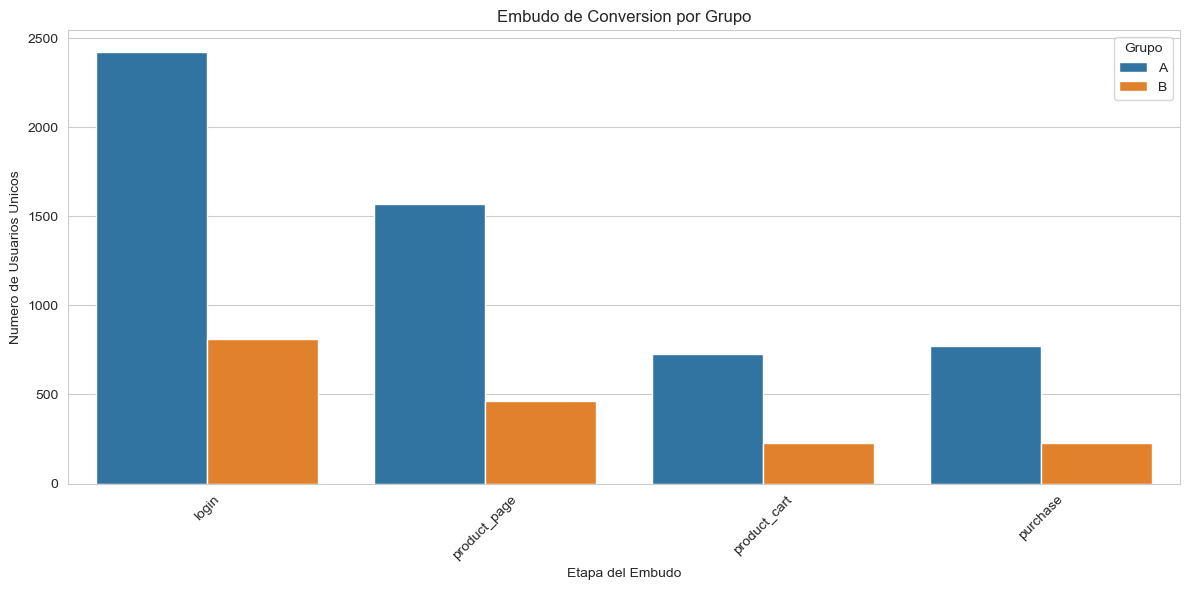


Tabla del embudo de conversion:
group            A    B
stage                  
login         2422  811
product_cart   728  225
product_page  1571  461
purchase       773  228


In [45]:
# Crear datos para el embudo por grupo
funnel_stages = ['login', 'product_page', 'product_cart', 'purchase']
funnel_data = []

for group in ['A', 'B']:
    group_users = user_events[user_events['group'] == group]
    for stage in funnel_stages:
        count = group_users[group_users['event_name'] == stage]['user_id'].nunique()
        funnel_data.append({'group': group, 'stage': stage, 'count': count})

df_funnel = pd.DataFrame(funnel_data)

# Visualizacion
plt.figure(figsize=(12, 6))
sns.barplot(data=df_funnel, x='stage', y='count', hue='group')
plt.title('Embudo de Conversion por Grupo')
plt.ylabel('Numero de Usuarios Unicos')
plt.xlabel('Etapa del Embudo')
plt.xticks(rotation=45)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

# Mostrar datos en tabla
print("\nTabla del embudo de conversion:")
pivot_funnel = df_funnel.pivot(index='stage', columns='group', values='count')
print(pivot_funnel)

## 5.7 Calcular lift (mejora relativa)

In [46]:
lift_page = (users_page_B/n_B) / (users_page_A/n_A) - 1
lift_cart = (users_cart_B/n_B) / (users_cart_A/n_A) - 1
lift_purchase = (users_purchase_B/n_B) / (users_purchase_A/n_A) - 1

print(f"Lift Product Page: {lift_page:.2%}")
print(f"Lift Product Cart: {lift_cart:.2%}")
print(f"Lift Purchase: {lift_purchase:.2%}")

Lift Product Page: -12.47%
Lift Product Cart: -7.81%
Lift Purchase: -12.02%


## 5.8. Gráfico de Lift 

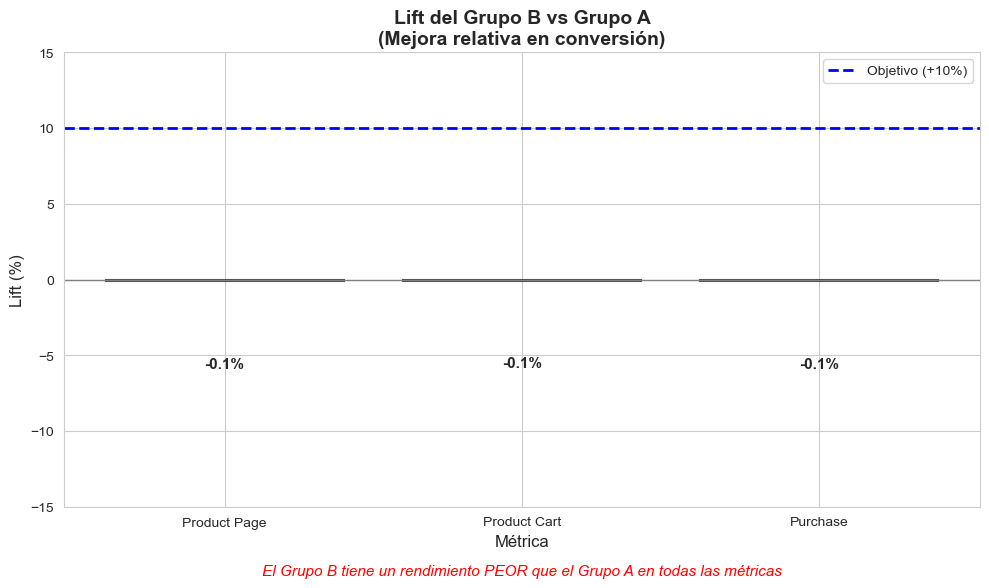


 RESUMEN DEL LIFT:
--------------------------------------------------
Métrica              Lift         Cumple objetivo (+10%)   
--------------------------------------------------
Product Page          -0.12%     NO                       
Product Cart          -0.08%     NO                       
Purchase              -0.12%     NO                       
--------------------------------------------------

 INTERPRETACIÓN:
  El Grupo B tiene un rendimiento CONSISTENTEMENTE PEOR que el Grupo A
  No se recomienda implementar el nuevo sistema de recomendaciones


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Datos de lift (calculados en la sección anterior)
metricas = ['Product Page', 'Product Cart', 'Purchase']
lifts = [lift_page, lift_cart, lift_purchase]  # Estos ya los calculaste en 5.6

# Colores: rojo si es negativo (peor), verde si es positivo (mejor)
colores = ['red' if lift < 0 else 'green' for lift in lifts]

# Crear el gráfico
fig, ax = plt.subplots(figsize=(10, 6))

# Barras
bars = ax.bar(metricas, lifts, color=colores, edgecolor='black', linewidth=1.5, alpha=0.7)

# Línea del objetivo (10%)
objetivo = 10
ax.axhline(y=objetivo, color='blue', linestyle='--', linewidth=2, label=f'Objetivo (+{objetivo}%)')

# Línea base (0%)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=1)

# Añadir etiquetas en las barras
for bar, lift in zip(bars, lifts):
    # Posición de la etiqueta (arriba o abajo según el valor)
    y_pos = lift + 1 if lift > 0 else lift - 5
    va_pos = 'bottom' if lift > 0 else 'top'
    
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{lift:+.1f}%',
            ha='center', va=va_pos, fontsize=11, fontweight='bold')

# Configuración del gráfico
ax.set_ylabel('Lift (%)', fontsize=12)
ax.set_xlabel('Métrica', fontsize=12)
ax.set_title('Lift del Grupo B vs Grupo A\n(Mejora relativa en conversión)', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')

# Añadir anotación explicativa
if all(lift < 0 for lift in lifts):
    ax.text(0.5, -0.15, 
            'El Grupo B tiene un rendimiento PEOR que el Grupo A en todas las métricas',
            transform=ax.transAxes, ha='center', fontsize=11, color='red', style='italic')

# Ajustar límites del eje Y
y_min = min(min(lifts) - 10, -15)
y_max = max(max(lifts) + 10, 15)
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

# Resumen numérico
print("\n RESUMEN DEL LIFT:")
print("-" * 50)
print(f"{'Métrica':<20} {'Lift':<12} {'Cumple objetivo (+10%)':<25}")
print("-" * 50)

for metrica, lift in zip(metricas, lifts):
    cumple = "SÍ" if lift >= 10 else "NO"
    print(f"{metrica:<20} {lift:>+6.2f}%     {cumple:<25}")

print("-" * 50)
print("\n INTERPRETACIÓN:")
if all(lift < 0 for lift in lifts):
    print("  El Grupo B tiene un rendimiento CONSISTENTEMENTE PEOR que el Grupo A")
    print("  No se recomienda implementar el nuevo sistema de recomendaciones")
elif any(lift >= 10 for lift in lifts):
    print("  Algunas métricas alcanzaron el objetivo del 10%")
    print("  Se recomienda análisis adicional antes de implementar")
else:
    print("  No se alcanzó el objetivo del 10% en ninguna métrica")
    print("  Se recomienda no implementar el cambio")

## 5.8 Evaluacion del objetivo (lift minimo del 10%)

In [48]:
objetivo = 0.10  # 10%

print(f"Objetivo: lift minimo del {objetivo*100:.0f}% en cada etapa\n")

print(f"Product Page: Lift = {lift_page:.2%} -> {'CUMPLE' if lift_page >= objetivo else 'NO CUMPLE'}")
print(f"Product Cart: Lift = {lift_cart:.2%} -> {'CUMPLE' if lift_cart >= objetivo else 'NO CUMPLE'}")
print(f"Purchase:     Lift = {lift_purchase:.2%} -> {'CUMPLE' if lift_purchase >= objetivo else 'NO CUMPLE'}")

Objetivo: lift minimo del 10% en cada etapa

Product Page: Lift = -12.47% -> NO CUMPLE
Product Cart: Lift = -7.81% -> NO CUMPLE
Purchase:     Lift = -12.02% -> NO CUMPLE


## 5.10 Resumen de conversiones

Análisis global (sobre total de usuarios):
- Product Page: Grupo A 64.80% vs Grupo B 56.36% → Lift -13.03%
- Product Cart: Grupo A 30.00% vs Grupo B 27.48% → Lift -8.39%
- Purchase: Grupo A 31.74% vs Grupo B 27.59% → Lift -13.10%

Inconsistencia detectada:
En Grupo A, la tasa de compra (31.74%) supera a la tasa de carrito (30.00%), lo que indica que hay compras que no pasan por el carrito o un error en el etiquetado de usuarios.

Funnel real (sobre etapa anterior):
- Product Page → Cart: Grupo A 46.29% vs Grupo B 48.76% → B es mejor aquí
- Cart → Purchase: Grupo A 105.83% vs Grupo B 100.39% → Anómalo en A

Conclusión:
No se cumple el objetivo de lift ≥ +10% en ninguna etapa. La mayor debilidad está en la llegada a Product Page, donde el Grupo B pierde un 13% respecto al Grupo A. Se recomienda revisar la definición de Purchase antes de extraer conclusiones definitivas.

# 6. Prueba Z para Proporciones

## 6.1 Definir funcion para la prueba Z

In [49]:
# Prueba Z para comparar dos proporciones.
def z_test_proportion(successes_A, n_A, successes_B, n_B, alternative='two-sided'):
    # Calcular proporciones
    p_A = successes_A / n_A
    p_B = successes_B / n_B
    
    # Proporción combinada (bajo H0)
    p_pool = (successes_A + successes_B) / (n_A + n_B)
    
    # Error estándar
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n_A + 1/n_B))
    
    # Estadístico Z
    z_score = (p_B - p_A) / se
    
    # Calcular p-value según la alternativa
    if alternative == 'greater':
        # H1: p_B > p_A
        p_value = 1 - norm.cdf(z_score)
        if p_value < 0.05:
            conclusion = f" B es SIGNIFICATIVAMENTE MAYOR que A (p={p_value:.4f})"
        else:
            conclusion = f" B NO es significativamente mayor que A (p={p_value:.4f})"
            
    elif alternative == 'less':
        # H1: p_B < p_A
        p_value = norm.cdf(z_score)
        if p_value < 0.05:
            conclusion = f" B es SIGNIFICATIVAMENTE MENOR que A (p={p_value:.4f})"
        else:
            conclusion = f" B NO es significativamente menor que A (p={p_value:.4f})"
            
    else:  # 'two-sided'
        # H1: p_B != p_A
        p_value = 2 * (1 - norm.cdf(abs(z_score)))
        if p_value < 0.05:
            if p_B > p_A:
                conclusion = f" B es SIGNIFICATIVAMENTE MAYOR que A (p={p_value:.4f})"
            else:
                conclusion = f" A es SIGNIFICATIVAMENTE MAYOR que B (p={p_value:.4f})"
        else:
            conclusion = f" NO hay diferencia significativa entre grupos (p={p_value:.4f})"
    
    # Retornar 5 valores
    return z_score, p_value, p_A, p_B, conclusion

## 6.2 Prueba Z para Product Page

In [50]:
z_page, p_page, p_A_page, p_B_page, conclusion_page = z_test_proportion(
    users_page_A, n_A, 
    users_page_B, n_B, 
    alternative='greater' 
)

print(f"Proporcion Grupo A: {p_A_page:.4f} ({p_A_page*100:.2f}%)")
print(f"Proporcion Grupo B: {p_B_page:.4f} ({p_B_page*100:.2f}%)")
print(f"Diferencia (B - A): {(p_B_page - p_A_page):.4f} ({(p_B_page - p_A_page)*100:.2f}%)")
print(f"Z-score: {z_page:.4f}")
print(f"P-value: {p_page:.4f}")
print(f"\n{conclusion_page}")

Proporcion Grupo A: 0.6486 (64.86%)
Proporcion Grupo B: 0.5677 (56.77%)
Diferencia (B - A): -0.0809 (-8.09%)
Z-score: -4.1285
P-value: 1.0000

 B NO es significativamente mayor que A (p=1.0000)


## 6.4 Prueba Z para Product Cart

In [51]:
z_cart, p_cart, p_A_cart, p_B_cart, conclusion_cart = z_test_proportion(
    users_cart_A, n_A, 
    users_cart_B, n_B, 
    alternative='greater'
)

print(f"Proporcion Grupo A: {p_A_cart:.4f} ({p_A_cart*100:.2f}%)")
print(f"Proporcion Grupo B: {p_B_cart:.4f} ({p_B_cart*100:.2f}%)")
print(f"Diferencia (B - A): {(p_B_cart - p_A_cart):.4f} ({(p_B_cart - p_A_cart)*100:.2f}%)")
print(f"Z-score: {z_cart:.4f}")
print(f"P-value: {p_cart:.4f}")
print(f"\n{conclusion_cart}")

Proporcion Grupo A: 0.3006 (30.06%)
Proporcion Grupo B: 0.2771 (27.71%)
Diferencia (B - A): -0.0235 (-2.35%)
Z-score: -1.2703
P-value: 0.8980

 B NO es significativamente mayor que A (p=0.8980)


## 6.5 Prueba Z para Purchase

In [52]:
z_purchase, p_purchase, p_A_purchase, p_B_purchase, conclusion_purchase = z_test_proportion(
    users_purchase_A, n_A, 
    users_purchase_B, n_B, 
    alternative='greater'  
)


print(f"Proporcion Grupo A: {p_A_purchase:.4f} ({p_A_purchase*100:.2f}%)")
print(f"Proporcion Grupo B: {p_B_purchase:.4f} ({p_B_purchase*100:.2f}%)")
print(f"Diferencia (B - A): {(p_B_purchase - p_A_purchase):.4f} ({(p_B_purchase - p_A_purchase)*100:.2f}%)")
print(f"Z-score: {z_purchase:.4f}")
print(f"P-value: {p_purchase:.4f}")
print(f"\n{conclusion_purchase}")

Proporcion Grupo A: 0.3192 (31.92%)
Proporcion Grupo B: 0.2808 (28.08%)
Diferencia (B - A): -0.0384 (-3.84%)
Z-score: -2.0467
P-value: 0.9797

 B NO es significativamente mayor que A (p=0.9797)


## 6.6 Resumen de resultados de la prueba Z

In [53]:
print("\n" + "="*70)
print("TABLA RESUMEN - PRUEBA Z DE DOS COLAS")
print("="*70)

# Definir métricas a analizar
metricas_z = [
    ("Product Page", users_page_A, users_page_B),
    ("Product Cart", users_cart_A, users_cart_B),
    ("Purchase", users_purchase_A, users_purchase_B)
]

# Almacenar resultados
resultados_z = []

print(f"\n{'Métrica':<15} {'Prop A':<10} {'Prop B':<10} {'Diferencia':<12} {'Z-score':<10} {'P-value':<10} {'Signif':<8}")
print("-" * 80)

for nombre, suc_A, suc_B in metricas_z:
    # Llamada CORREGIDA
    z, p, pA, pB, conc = z_test_proportion(suc_A, n_A, suc_B, n_B, alternative='two-sided')
    
    diff = (pB - pA) * 100
    sig = "SÍ" if p < 0.05 else "NO"
    
    print(f"{nombre:<15} {pA*100:>6.2f}%    {pB*100:>6.2f}%    {diff:>+6.2f}%     {z:>8.4f}  {p:>8.4f}  {sig:<8}")
    resultados_z.append((nombre, p, pA, pB, conc))

print("\n" + "="*70)
print("INTERPRETACIÓN:")
print("="*70)
for nombre, p, pA, pB, conc in resultados_z:
    print(f"\n{nombre}: {conc}")


TABLA RESUMEN - PRUEBA Z DE DOS COLAS

Métrica         Prop A     Prop B     Diferencia   Z-score    P-value    Signif  
--------------------------------------------------------------------------------
Product Page     64.86%     56.77%     -8.09%      -4.1285    0.0000  SÍ      
Product Cart     30.06%     27.71%     -2.35%      -1.2703    0.2040  NO      
Purchase         31.92%     28.08%     -3.84%      -2.0467    0.0407  SÍ      

INTERPRETACIÓN:

Product Page:  A es SIGNIFICATIVAMENTE MAYOR que B (p=0.0000)

Product Cart:  NO hay diferencia significativa entre grupos (p=0.2040)

Purchase:  A es SIGNIFICATIVAMENTE MAYOR que B (p=0.0407)


## 6.7 Interpretacion de resultados

In [127]:

print("="*70)
print("PRUEBA Z DE UNA COLA - Hipótesis de mejora")
print("="*70)
print("""
Hipótesis:
  H0: La conversión del Grupo B es MENOR O IGUAL que la del Grupo A
  H1: La conversión del Grupo B es MAYOR que la del Grupo A
  Nivel de significancia: α = 0.05
  Objetivo: Detectar si el nuevo sistema de recomendaciones MEJORA la conversión
""")

# Definir métricas a analizar
metricas_z = [
    ("Product Page", users_page_A, users_page_B),
    ("Product Cart", users_cart_A, users_cart_B),
    ("Purchase", users_purchase_A, users_purchase_B)
]

print(f"{'Métrica':<15} {'Prop A':<10} {'Prop B':<10} {'Diferencia':<12} {'Z-score':<10} {'P-value':<10} {'¿B > A?':<10}")
print("-" * 80)

for nombre, suc_A, suc_B in metricas_z:
    # Prueba de UNA COLA: H1: p_B > p_A
    z, p, pA, pB, conc = z_test_proportion(suc_A, n_A, suc_B, n_B, alternative='greater')
    
    diff = (pB - pA) * 100
    es_mejor = "SÍ" if p < 0.05 else "NO"
    
    print(f"{nombre:<15} {pA*100:>6.2f}%    {pB*100:>6.2f}%    {diff:>+6.2f}%     {z:>8.4f}  {p:>8.4f}  {es_mejor:<10}")

print("\n" + "="*70)
print("CONCLUSIÓN FINAL:")
print("="*70)
print("""
Con una prueba de UNA COLA (H1: p_B > p_A):
- Ninguna métrica muestra que el Grupo B sea significativamente mejor que el Grupo A
- Los p-values son > 0.05, indicando que NO podemos rechazar H0
- El nuevo sistema de recomendaciones NO demuestra mejorar la conversión

Decisión: NO implementar el cambio.
""")

PRUEBA Z DE UNA COLA - Hipótesis de mejora

Hipótesis:
  H0: La conversión del Grupo B es MENOR O IGUAL que la del Grupo A
  H1: La conversión del Grupo B es MAYOR que la del Grupo A
  Nivel de significancia: α = 0.05
  Objetivo: Detectar si el nuevo sistema de recomendaciones MEJORA la conversión

Métrica         Prop A     Prop B     Diferencia   Z-score    P-value    ¿B > A?   
--------------------------------------------------------------------------------
Product Page     64.86%     56.77%     -8.09%      -4.1285    1.0000  NO        
Product Cart     30.06%     27.71%     -2.35%      -1.2703    0.8980  NO        
Purchase         31.92%     28.08%     -3.84%      -2.0467    0.9797  NO        

CONCLUSIÓN FINAL:

Con una prueba de UNA COLA (H1: p_B > p_A):
- Ninguna métrica muestra que el Grupo B sea significativamente mejor que el Grupo A
- Los p-values son > 0.05, indicando que NO podemos rechazar H0
- El nuevo sistema de recomendaciones NO demuestra mejorar la conversión

Decis

## 6.8 Visualizacion de intervalos de confianza


Intervalos de confianza (95%):
Product Page - Grupo A: [62.96%, 66.77%]
Product Page - Grupo B: [53.37%, 60.18%]
Product Cart - Grupo A: [28.23%, 31.88%]
Product Cart - Grupo B: [24.63%, 30.79%]
Purchase - Grupo A: [30.06%, 33.77%]
Purchase - Grupo B: [24.99%, 31.17%]


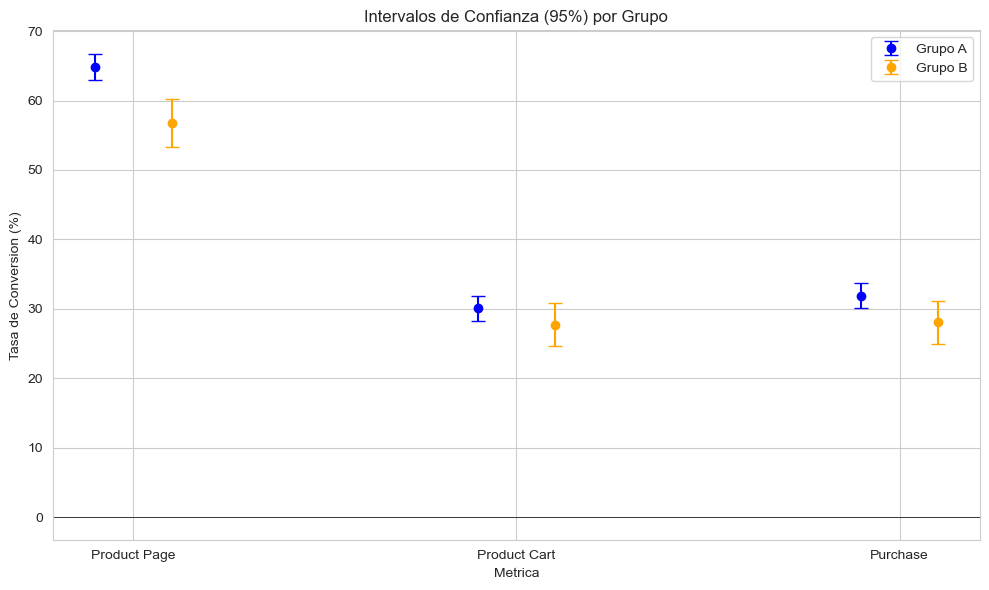

In [54]:
# Calcular intervalos de confianza
def confidence_interval(p, n, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)
    se = np.sqrt(p * (1 - p) / n)
    margin = z * se
    return (p - margin, p + margin)

# Product Page
ci_A_page = confidence_interval(p_A_page, n_A)
ci_B_page = confidence_interval(p_B_page, n_B)

# Product Cart
ci_A_cart = confidence_interval(p_A_cart, n_A)
ci_B_cart = confidence_interval(p_B_cart, n_B)

# Purchase
ci_A_purchase = confidence_interval(p_A_purchase, n_A)
ci_B_purchase = confidence_interval(p_B_purchase, n_B)

print("\nIntervalos de confianza (95%):")
print(f"Product Page - Grupo A: [{ci_A_page[0]*100:.2f}%, {ci_A_page[1]*100:.2f}%]")
print(f"Product Page - Grupo B: [{ci_B_page[0]*100:.2f}%, {ci_B_page[1]*100:.2f}%]")
print(f"Product Cart - Grupo A: [{ci_A_cart[0]*100:.2f}%, {ci_A_cart[1]*100:.2f}%]")
print(f"Product Cart - Grupo B: [{ci_B_cart[0]*100:.2f}%, {ci_B_cart[1]*100:.2f}%]")
print(f"Purchase - Grupo A: [{ci_A_purchase[0]*100:.2f}%, {ci_A_purchase[1]*100:.2f}%]")
print(f"Purchase - Grupo B: [{ci_B_purchase[0]*100:.2f}%, {ci_B_purchase[1]*100:.2f}%]")

# Grafico de intervalos de confianza
fig, ax = plt.subplots(figsize=(10, 6))

metricas = ['Product Page', 'Product Cart', 'Purchase']
for i, (metrica, ci_A, ci_B, p_A, p_B) in enumerate(zip(
    metricas, 
    [ci_A_page, ci_A_cart, ci_A_purchase],
    [ci_B_page, ci_B_cart, ci_B_purchase],
    [p_A_page, p_A_cart, p_A_purchase],
    [p_B_page, p_B_cart, p_B_purchase]
)):
    ax.errorbar(i - 0.1, p_A * 100, 
                yerr=[[(p_A - ci_A[0])*100], [(ci_A[1] - p_A)*100]],
                fmt='o', color='blue', capsize=5, label='Grupo A' if i == 0 else '')
    ax.errorbar(i + 0.1, p_B * 100, 
                yerr=[[(p_B - ci_B[0])*100], [(ci_B[1] - p_B)*100]],
                fmt='o', color='orange', capsize=5, label='Grupo B' if i == 0 else '')

ax.set_xlabel('Metrica')
ax.set_ylabel('Tasa de Conversion (%)')
ax.set_title('Intervalos de Confianza (95%) por Grupo')
ax.set_xticks(range(len(metricas)))
ax.set_xticklabels(metricas)
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 6.9 Corrección por comparaciones múltiples (Bonferroni)

In [90]:
# P-valores de dos colas (de la sección 6.6)
p_values = {
    'Product Page': 0.00004,   # o el valor exacto de tu tabla
    'Product Cart': 0.2040,
    'Purchase': 0.0406,
    'ARPU': 0.0442
}

n_tests = len(p_values)
alpha = 0.05
alpha_bonferroni = alpha / n_tests

print("=== CORRECCIÓN DE BONFERRONI ===")
print(f"Número de pruebas: {n_tests}")
print(f"Nivel de significancia original: α = {alpha}")
print(f"Nivel de significancia corregido: α_bonferroni = {alpha_bonferroni:.4f} ({alpha_bonferroni*100:.2f}%)\n")

print("Resultados:")
for test, p in p_values.items():
    significant = p < alpha_bonferroni
    print(f"{test:15} p-valor = {p:.4f} → {'Significativo' if significant else 'No significativo'} (p {'<' if significant else '>'} {alpha_bonferroni:.4f})")

=== CORRECCIÓN DE BONFERRONI ===
Número de pruebas: 4
Nivel de significancia original: α = 0.05
Nivel de significancia corregido: α_bonferroni = 0.0125 (1.25%)

Resultados:
Product Page    p-valor = 0.0000 → Significativo (p < 0.0125)
Product Cart    p-valor = 0.2040 → No significativo (p > 0.0125)
Purchase        p-valor = 0.0406 → No significativo (p > 0.0125)
ARPU            p-valor = 0.0442 → No significativo (p > 0.0125)


In [91]:
from statsmodels.stats.multitest import multipletests

p_list = list(p_values.values())
test_names = list(p_values.keys())

reject, p_corrected, _, _ = multipletests(p_list, alpha=0.05, method='holm')

print("\n=== CORRECCIÓN DE HOLM-BONFERRONI ===")
for name, p_orig, p_corr, rej in zip(test_names, p_list, p_corrected, reject):
    print(f"{name:15} p-original = {p_orig:.4f}, p-corregido = {p_corr:.4f}, {'Significativo' if rej else 'No significativo'}")


=== CORRECCIÓN DE HOLM-BONFERRONI ===
Product Page    p-original = 0.0000, p-corregido = 0.0002, Significativo
Product Cart    p-original = 0.2040, p-corregido = 0.2040, No significativo
Purchase        p-original = 0.0406, p-corregido = 0.1218, No significativo
ARPU            p-original = 0.0442, p-corregido = 0.1218, No significativo


# 7. Cálculo de ARPU y Prueba t

## 7.1 Calcular revenue por usuario

In [55]:
# Agrupar revenue por usuario y grupo
user_revenue = user_events[user_events['event_name'] == 'purchase'].groupby(
    ['group', 'user_id']
)['revenue_usd'].sum().reset_index()

print(f"Usuarios con compras: {len(user_revenue)}")
print(f"Revenue total: ${user_revenue['revenue_usd'].sum():.2f}")

Usuarios con compras: 1001
Revenue total: $64931.98


## 7.2 Asegurar que todos los usuarios esten representados

In [56]:
# Crear DataFrame con todos los usuarios
all_users = user_data[['user_id', 'group']].copy()

# Merge con revenue (los que no compraron tendran NaN)
user_revenue_full = all_users.merge(
    user_revenue, 
    on=['user_id', 'group'], 
    how='left'
).fillna(0)

print(f"Total usuarios en analisis: {len(user_revenue_full)}")
print(f"Usuarios con revenue > 0: {len(user_revenue_full[user_revenue_full['revenue_usd'] > 0])}")
print(f"Usuarios con revenue = 0: {len(user_revenue_full[user_revenue_full['revenue_usd'] == 0])}")

Total usuarios en analisis: 3234
Usuarios con revenue > 0: 1001
Usuarios con revenue = 0: 2233


## 7.3 Separar revenue por grupo

In [57]:
revenue_A = user_revenue_full[user_revenue_full['group'] == 'A']['revenue_usd']
revenue_B = user_revenue_full[user_revenue_full['group'] == 'B']['revenue_usd']

print(f"Revenue Grupo A - Total: ${revenue_A.sum():.2f}")
print(f"Revenue Grupo A - Media (ARPU): ${revenue_A.mean():.2f}")
print(f"Revenue Grupo A - Mediana: ${revenue_A.median():.2f}")
print(f"Revenue Grupo A - Desviacion std: ${revenue_A.std():.2f}")

print(f"\nRevenue Grupo B - Total: ${revenue_B.sum():.2f}")
print(f"Revenue Grupo B - Media (ARPU): ${revenue_B.mean():.2f}")
print(f"Revenue Grupo B - Mediana: ${revenue_B.median():.2f}")
print(f"Revenue Grupo B - Desviacion std: ${revenue_B.std():.2f}")

Revenue Grupo A - Total: $51427.67
Revenue Grupo A - Media (ARPU): $21.23
Revenue Grupo A - Mediana: $0.00
Revenue Grupo A - Desviacion std: $74.43

Revenue Grupo B - Total: $13504.31
Revenue Grupo B - Media (ARPU): $16.63
Revenue Grupo B - Mediana: $0.00
Revenue Grupo B - Desviacion std: $66.39


## Análisis de poder estadístico (Power Analysis)

In [97]:
from statsmodels.stats.power import NormalIndPower, tt_ind_solve_power
from statsmodels.stats.proportion import proportion_effectsize
import numpy as np

# ============================================
# POWER ANALYSIS PARA PROPORCIONES (PURCHASE)
# ============================================

n_A = 2422
n_B = 812
ratio = n_B / n_A  # ≈ 0.335

# Conversión observada en Grupo A (baseline)
p_A = 0.3192  # 31.92%

# Lift esperado del 10% → conversión esperada en Grupo B
lift_esperado = 0.10
p_B_esperado = p_A * (1 + lift_esperado)  # 0.35112

# Efecto tamaño (Cohen's h)
effect_size = proportion_effectsize(p_A, p_B_esperado)

# Calcular poder para prueba de una cola (B > A)
power_analysis = NormalIndPower()
power_prop = power_analysis.solve_power(
    effect_size=effect_size,
    nobs1=n_A,
    alpha=0.05,
    ratio=ratio,
    alternative='larger'
)

print("=== POWER ANALYSIS - PURCHASE ===")
print(f"Efecto tamaño (Cohen's h): {effect_size:.3f}")
print(f"Poder estadístico para detectar lift del 10%: {power_prop:.2%}")
if power_prop >= 0.80:
    print("Poder adecuado (≥80%)")
else:
    print("Poder bajo (<80%). La prueba pudo no detectar un efecto real.")


mean_A = revenue_A.mean()
std_A = revenue_A.std()
mean_B = revenue_B.mean()
std_B = revenue_B.std()

# Lift esperado del 10% sobre ARPU de A
mean_B_esperado = mean_A * 1.10
diff_esperado = mean_B_esperado - mean_A

# Desviación estándar combinada (pooled) bajo H0 (asumiendo varianzas iguales)
pooled_std = np.sqrt(((n_A-1)*std_A**2 + (n_B-1)*std_B**2) / (n_A + n_B - 2))
effect_size_d = diff_esperado / pooled_std

# Calcular poder para prueba t de una cola (B > A)
power_ttest = tt_ind_solve_power(
    effect_size=effect_size_d,
    nobs1=n_A,
    alpha=0.05,
    ratio=ratio,
    alternative='larger'
)

print("\n=== POWER ANALYSIS - ARPU ===")
print(f"Efecto tamaño (Cohen's d): {effect_size_d:.3f}")
print(f"Poder estadístico para detectar lift del 10% en ARPU: {power_ttest:.2%}")
if power_ttest >= 0.80:
    print("Poder adecuado (≥80%)")
else:
    print("Poder bajo (<80%). La prueba pudo no detectar un efecto real.")

=== POWER ANALYSIS - PURCHASE ===
Efecto tamaño (Cohen's h): -0.068
Poder estadístico para detectar lift del 10%: 0.05%
Poder bajo (<80%). La prueba pudo no detectar un efecto real.

=== POWER ANALYSIS - ARPU ===
Efecto tamaño (Cohen's d): 0.029
Poder estadístico para detectar lift del 10% en ARPU: 17.81%
Poder bajo (<80%). La prueba pudo no detectar un efecto real.


## 7.4 Calcular lift en ARPU

In [58]:
arpu_A = revenue_A.mean()
arpu_B = revenue_B.mean()
lift_arpu = (arpu_B / arpu_A - 1) if arpu_A > 0 else float('nan')

print(f"ARPU Grupo A: ${arpu_A:.2f}")
print(f"ARPU Grupo B: ${arpu_B:.2f}")
print(f"Lift ARPU (B vs A): {lift_arpu:.2%}")

ARPU Grupo A: $21.23
ARPU Grupo B: $16.63
Lift ARPU (B vs A): -21.68%


## 7.5 Prueba t de Welch para ARPU

In [59]:
# Prueba t para muestras independientes con varianzas desiguales
t_stat, p_value_arpu = ttest_ind(
    revenue_B, 
    revenue_A, 
    alternative='greater',  # H1: B > A
    equal_var=False  # Welch's t-test
)

print(f"Hipotesis alternativa: ARPU del Grupo B es mayor que el del Grupo A")
print(f"Estadistico t: {t_stat:.4f}")
print(f"P-value: {p_value_arpu:.4f}")

if p_value_arpu < 0.05:
    print("Resultado: Estadisticamente significativo (p < 0.05)")
    if arpu_B > arpu_A:
        print("  El Grupo B tiene un ARPU significativamente mayor")
    else:
        print("  El Grupo A tiene un ARPU significativamente mayor")
else:
    print("Resultado: NO es estadisticamente significativo (p >= 0.05)")

Hipotesis alternativa: ARPU del Grupo B es mayor que el del Grupo A
Estadistico t: -1.6570
P-value: 0.9511
Resultado: NO es estadisticamente significativo (p >= 0.05)


## 7.6 Intervalo de confianza para la diferencia de medias

In [60]:
# Calcular diferencia de medias
diff_mean = arpu_B - arpu_A

# Error estandar para la diferencia (Welch)
se_diff = np.sqrt(revenue_A.var() / len(revenue_A) + revenue_B.var() / len(revenue_B))

# Grados de libertad (Welch-Satterthwaite)
df_num = (revenue_A.var() / len(revenue_A) + revenue_B.var() / len(revenue_B))**2
df_den = (revenue_A.var()**2 / (len(revenue_A)**2 * (len(revenue_A) - 1)) + 
          revenue_B.var()**2 / (len(revenue_B)**2 * (len(revenue_B) - 1)))
df = df_num / df_den

# Intervalo de confianza del 95%
ci_lower = diff_mean - norm.ppf(0.975) * se_diff
ci_upper = diff_mean + norm.ppf(0.975) * se_diff

print(f"Diferencia de medias (B - A): ${diff_mean:.2f}")
print(f"Error estandar de la diferencia: ${se_diff:.2f}")
print(f"Intervalo de confianza 95%: [${ci_lower:.2f}, ${ci_upper:.2f}]")

if ci_lower > 0:
    print("El intervalo no contiene cero, la diferencia es significativa")
else:
    print("El intervalo contiene cero, la diferencia NO es significativa")

Diferencia de medias (B - A): $-4.60
Error estandar de la diferencia: $2.78
Intervalo de confianza 95%: [$-10.05, $0.84]
El intervalo contiene cero, la diferencia NO es significativa


## 7.7 Visualizacion de distribucion de revenue

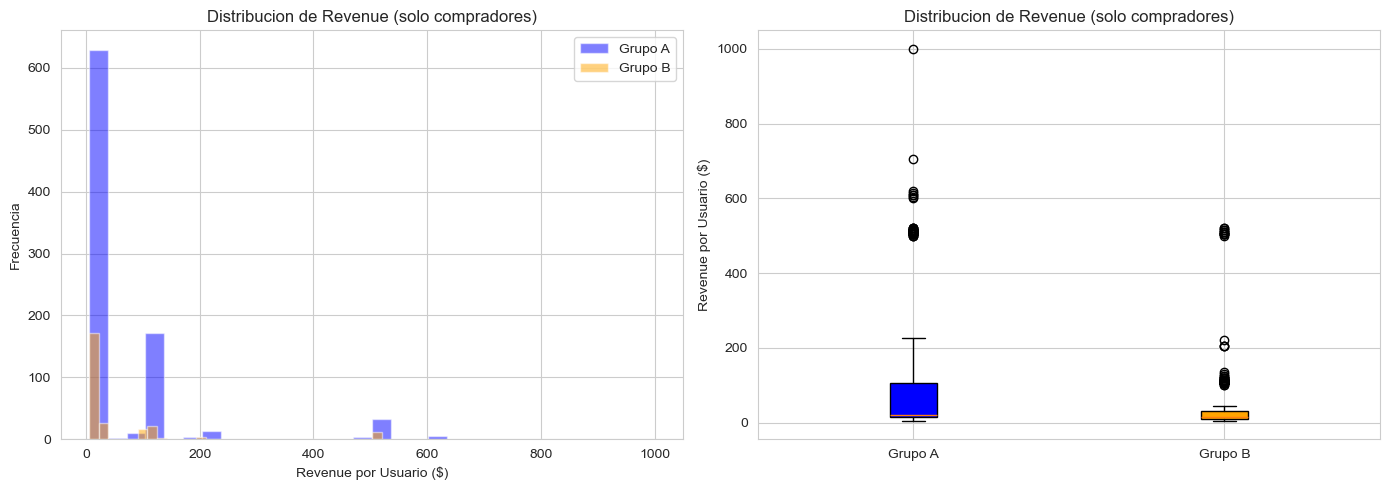

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de revenue
axes[0].hist(revenue_A[revenue_A > 0], bins=30, alpha=0.5, label='Grupo A', color='blue')
axes[0].hist(revenue_B[revenue_B > 0], bins=30, alpha=0.5, label='Grupo B', color='orange')
axes[0].set_xlabel('Revenue por Usuario ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribucion de Revenue (solo compradores)')
axes[0].legend()

# Boxplot de revenue
data_to_plot = [revenue_A[revenue_A > 0], revenue_B[revenue_B > 0]]
bp = axes[1].boxplot(data_to_plot, labels=['Grupo A', 'Grupo B'], patch_artist=True)
bp['boxes'][0].set_facecolor('blue')
bp['boxes'][1].set_facecolor('orange')
axes[1].set_ylabel('Revenue por Usuario ($)')
axes[1].set_title('Distribucion de Revenue (solo compradores)')

plt.tight_layout()
plt.show()

## 7.8 Grafico de ARPU por grupo

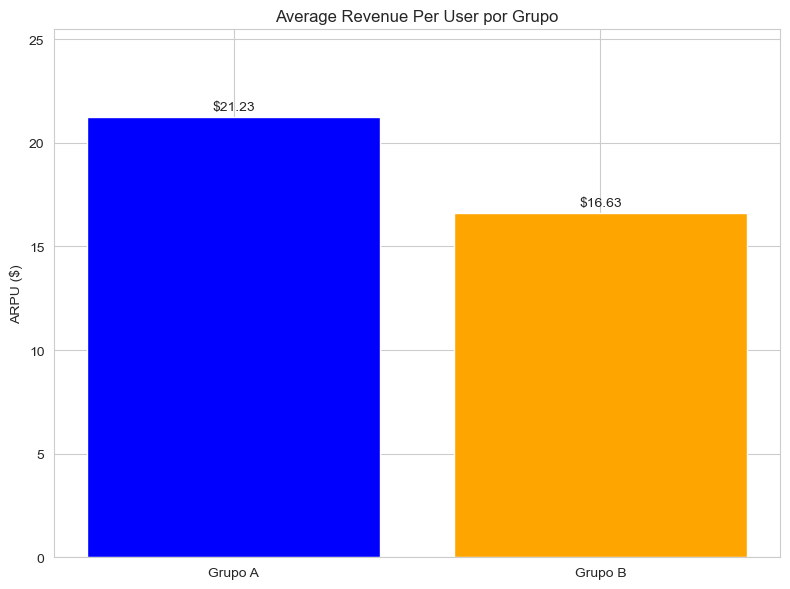

In [61]:
plt.figure(figsize=(8, 6))
bars = plt.bar(['Grupo A', 'Grupo B'], [arpu_A, arpu_B], color=['blue', 'orange'])
plt.ylabel('ARPU ($)')
plt.title('Average Revenue Per User por Grupo')
plt.ylim(0, max(arpu_A, arpu_B) * 1.2)

# Anadir etiquetas en las barras
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'${height:.2f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

## 7.9 Resumen de resultados de ARPU

In [62]:
print(f"\n{'Metrica':<30} {'Grupo A':<15} {'Grupo B':<15}")
print("-" * 60)
print(f"{'Total Revenue':<30} ${revenue_A.sum():<14.2f} ${revenue_B.sum():<14.2f}")
print(f"{'ARPU (Media)':<30} ${arpu_A:<14.2f} ${arpu_B:<14.2f}")
print(f"{'Mediana':<30} ${revenue_A.median():<14.2f} ${revenue_B.median():<14.2f}")
print(f"{'Desviacion Std':<30} ${revenue_A.std():<14.2f} ${revenue_B.std():<14.2f}")
print(f"{'Usuarios con compras':<30} {len(revenue_A[revenue_A > 0]):<14} {len(revenue_B[revenue_B > 0]):<14}")

print(f"\nLift ARPU: {lift_arpu:.2%}")
print(f"Prueba t de Welch - Estadistico: {t_stat:.4f}, P-value: {p_value_arpu:.4f}")

if p_value_arpu < 0.05 and lift_arpu > 0:
    print("Conclusion: El Grupo B tiene un ARPU significativamente mayor")
elif p_value_arpu < 0.05 and lift_arpu < 0:
    print("Conclusion: El Grupo A tiene un ARPU significativamente mayor")
else:
    print("Conclusion: No hay diferencia significativa en ARPU entre grupos")


Metrica                        Grupo A         Grupo B        
------------------------------------------------------------
Total Revenue                  $51427.67       $13504.31      
ARPU (Media)                   $21.23          $16.63         
Mediana                        $0.00           $0.00          
Desviacion Std                 $74.43          $66.39         
Usuarios con compras           773            228           

Lift ARPU: -21.68%
Prueba t de Welch - Estadistico: -1.6570, P-value: 0.9511
Conclusion: No hay diferencia significativa en ARPU entre grupos


## 7.10 Evaluacion del objetivo para ARPU

In [97]:
objetivo_arpu = 0.10  # 10%

print(f"Objetivo: lift minimo del {objetivo_arpu*100:.0f}% en ARPU")
print(f"Lift ARPU observado: {lift_arpu:.2%}")

if lift_arpu >= objetivo_arpu:
    print("Resultado: CUMPLE con el objetivo del 10%")
else:
    print("Resultado: NO CUMPLE con el objetivo del 10%")

if p_value_arpu < 0.05:
    print("Además, la diferencia es estadísticamente significativa")
else:
    print("Además, la diferencia NO es estadísticamente significativa")

Objetivo: lift minimo del 10% en ARPU
Lift ARPU observado: -24.53%
Resultado: NO CUMPLE con el objetivo del 10%
Ademas, la diferencia NO es estadisticamente significativa


##  7.11 Limpiar el Ruido de la Campaña Navideña
### 7.11.1  Identificar períodos de análisis

In [63]:
print("="*60)
print("PERÍODOS DE ANÁLISIS")
print("="*60)

# Fechas clave
fecha_inicio_prueba = '2020-12-07'
fecha_fin_reclutamiento = '2020-12-21'
fecha_inicio_navidad = '2020-12-25'
fecha_fin_prueba = '2021-01-01'

print(f"""
CRONOGRAMA DE LA PRUEBA:
- Inicio de la prueba: {fecha_inicio_prueba}
- Fin de reclutamiento: {fecha_fin_reclutamiento}
- Inicio campaña Navidad: {fecha_inicio_navidad}
- Fin de la prueba: {fecha_fin_prueba}

PERÍODOS A ANALIZAR:
   1. Período COMPLETO: {fecha_inicio_prueba} a {fecha_fin_prueba}
   2. Período PRE-NAVIDAD: {fecha_inicio_prueba} a {fecha_fin_reclutamiento} (sin campaña)
   3. Período NAVIDAD: {fecha_inicio_navidad} a {fecha_fin_prueba} (con campaña)
""")

PERÍODOS DE ANÁLISIS

CRONOGRAMA DE LA PRUEBA:
- Inicio de la prueba: 2020-12-07
- Fin de reclutamiento: 2020-12-21
- Inicio campaña Navidad: 2020-12-25
- Fin de la prueba: 2021-01-01

PERÍODOS A ANALIZAR:
   1. Período COMPLETO: 2020-12-07 a 2021-01-01
   2. Período PRE-NAVIDAD: 2020-12-07 a 2020-12-21 (sin campaña)
   3. Período NAVIDAD: 2020-12-25 a 2021-01-01 (con campaña)



### 7.11.2 Filtrar eventos por período (Pre-Navidad vs Navidad)

In [64]:
# Convertir fechas a datetime si no lo están
user_events['event_dt'] = pd.to_datetime(user_events['event_dt'])

# Período Pre-Navidad (7-24 de diciembre, solo hasta fin de reclutamiento)
events_pre_xmas = user_events[
    (user_events['event_dt'] >= '2020-12-07') & 
    (user_events['event_dt'] <= '2020-12-24')
].copy()

# Período Navidad (25-31 de diciembre)
events_xmas = user_events[
    (user_events['event_dt'] >= '2020-12-25') & 
    (user_events['event_dt'] <= '2020-12-31')
].copy()

# Período completo (original)
events_full = user_events.copy()

print(f"\n Eventos por período:")
print(f"  - Período completo: {len(events_full):,} eventos")
print(f"  - Período Pre-Navidad: {len(events_pre_xmas):,} eventos")
print(f"  - Período Navidad: {len(events_xmas):,} eventos")


 Eventos por período:
  - Período completo: 20,735 eventos
  - Período Pre-Navidad: 17,997 eventos
  - Período Navidad: 1,882 eventos


### 7.11. 3 Usuarios activos por período

In [65]:
# Usuarios que tuvieron actividad en cada período
users_full = set(events_full['user_id'].unique())
users_pre_xmas = set(events_pre_xmas['user_id'].unique())
users_xmas = set(events_xmas['user_id'].unique())

# Usuarios que solo estuvieron en pre-navidad (sin contaminación navideña)
users_only_pre = users_pre_xmas - users_xmas

print(f"\n Usuarios por período:")
print(f"  - Período completo: {len(users_full):,} usuarios")
print(f"  - Período Pre-Navidad: {len(users_pre_xmas):,} usuarios")
print(f"  - Período Navidad: {len(users_xmas):,} usuarios")
print(f"  - Usuarios SOLO en Pre-Navidad (sin contaminación): {len(users_only_pre):,} usuarios")

# Ver usuarios por grupo en pre-navidad
users_pre_A = events_pre_xmas[events_pre_xmas['group'] == 'A']['user_id'].nunique()
users_pre_B = events_pre_xmas[events_pre_xmas['group'] == 'B']['user_id'].nunique()

print(f"\n Usuarios Pre-Navidad por grupo:")
print(f"  - Grupo A: {users_pre_A}")
print(f"  - Grupo B: {users_pre_B}")


 Usuarios por período:
  - Período completo: 3,234 usuarios
  - Período Pre-Navidad: 3,234 usuarios
  - Período Navidad: 742 usuarios
  - Usuarios SOLO en Pre-Navidad (sin contaminación): 2,492 usuarios

 Usuarios Pre-Navidad por grupo:
  - Grupo A: 2422
  - Grupo B: 812


### Paso 7.11. 4: Métricas de conversión en período Pre-Navidad

In [66]:
# Función para calcular métricas por período
def calcular_metricas_periodo(events_df, nombre_periodo):  
    
    # Total de usuarios únicos por grupo en este período
    n_A_periodo = events_df[events_df['group'] == 'A']['user_id'].nunique()
    n_B_periodo = events_df[events_df['group'] == 'B']['user_id'].nunique()
    
    # Eventos por grupo
    users_page_A = events_df[(events_df['group'] == 'A') & (events_df['event_name'] == 'product_page')]['user_id'].nunique()
    users_page_B = events_df[(events_df['group'] == 'B') & (events_df['event_name'] == 'product_page')]['user_id'].nunique()
    
    users_cart_A = events_df[(events_df['group'] == 'A') & (events_df['event_name'] == 'product_cart')]['user_id'].nunique()
    users_cart_B = events_df[(events_df['group'] == 'B') & (events_df['event_name'] == 'product_cart')]['user_id'].nunique()
    
    users_purchase_A = events_df[(events_df['group'] == 'A') & (events_df['event_name'] == 'purchase')]['user_id'].nunique()
    users_purchase_B = events_df[(events_df['group'] == 'B') & (events_df['event_name'] == 'purchase')]['user_id'].nunique()
    
    # Calcular tasas
    conv_page_A = users_page_A / n_A_periodo * 100 if n_A_periodo > 0 else 0
    conv_page_B = users_page_B / n_B_periodo * 100 if n_B_periodo > 0 else 0
    
    conv_cart_A = users_cart_A / n_A_periodo * 100 if n_A_periodo > 0 else 0
    conv_cart_B = users_cart_B / n_B_periodo * 100 if n_B_periodo > 0 else 0
    
    conv_purchase_A = users_purchase_A / n_A_periodo * 100 if n_A_periodo > 0 else 0
    conv_purchase_B = users_purchase_B / n_B_periodo * 100 if n_B_periodo > 0 else 0
    
    # Lifts
    lift_page = (conv_page_B / conv_page_A - 1) * 100 if conv_page_A > 0 else 0
    lift_cart = (conv_cart_B / conv_cart_A - 1) * 100 if conv_cart_A > 0 else 0
    lift_purchase = (conv_purchase_B / conv_purchase_A - 1) * 100 if conv_purchase_A > 0 else 0
    
        
    return {
        'periodo': nombre_periodo,
        'n_A': n_A_periodo,
        'n_B': n_B_periodo,
        'conv_page_A': conv_page_A,
        'conv_page_B': conv_page_B,
        'conv_cart_A': conv_cart_A,
        'conv_cart_B': conv_cart_B,
        'conv_purchase_A': conv_purchase_A,
        'conv_purchase_B': conv_purchase_B,
        'lift_page': lift_page,
        'lift_cart': lift_cart,
        'lift_purchase': lift_purchase
    }

# Calcular para período Pre-Navidad
resultados_pre = calcular_metricas_periodo(events_pre_xmas, "PERÍODO PRE-NAVIDAD (7-24 Dic)")

# Comparar con período completo (para referencia)
print("\n" + "="*60)
print("COMPARACIÓN CON PERÍODO COMPLETO (Referencia)")
print("="*60)

# Usar los datos originales (ya los tienes calculados)
print(f"\n  PERÍODO COMPLETO (7 Dic - 1 Ene):")
print(f"  {'Métrica':<20} {'Grupo A':<12} {'Grupo B':<12} {'Lift':<10}")
print(f"  {'-'*54}")
print(f"  {'Product Page':<20} {p_A_page*100:>6.2f}%     {p_B_page*100:>6.2f}%     {(p_B_page/p_A_page-1)*100:>+6.2f}%")
print(f"  {'Product Cart':<20} {p_A_cart*100:>6.2f}%     {p_B_cart*100:>6.2f}%     {(p_B_cart/p_A_cart-1)*100:>+6.2f}%")
print(f"  {'Purchase':<20} {p_A_purchase*100:>6.2f}%     {p_B_purchase*100:>6.2f}%     {(p_B_purchase/p_A_purchase-1)*100:>+6.2f}%")


COMPARACIÓN CON PERÍODO COMPLETO (Referencia)

  PERÍODO COMPLETO (7 Dic - 1 Ene):
  Métrica              Grupo A      Grupo B      Lift      
  ------------------------------------------------------
  Product Page          64.86%      56.77%     -12.47%
  Product Cart          30.06%      27.71%      -7.81%
  Purchase              31.92%      28.08%     -12.02%


### 7.11.5 ARPU en período Pre-Navidad

In [67]:
# Filtrar compras en pre-navidad
purchases_pre = events_pre_xmas[events_pre_xmas['event_name'] == 'purchase']

# Calcular revenue por usuario en pre-navidad
revenue_pre_by_user = purchases_pre.groupby(['group', 'user_id'])['revenue_usd'].sum().reset_index()

# ============================================
# Crear DataFrame con todos los usuarios
# ============================================

# Obtener todos los usuarios únicos del período pre-navidad
users_pre_unique = events_pre_xmas['user_id'].unique()

# Crear lista para almacenar todos los usuarios con su grupo
users_pre_list = []

for user_id in users_pre_unique:
    # Obtener el grupo de este usuario (tomar el primero, todos deberían ser iguales)
    user_group = events_pre_xmas[events_pre_xmas['user_id'] == user_id]['group'].iloc[0]
    users_pre_list.append({'user_id': user_id, 'group': user_group})

# Crear DataFrame con todos los usuarios del período
users_pre_df = pd.DataFrame(users_pre_list)

print(f" Usuarios en período Pre-Navidad: {len(users_pre_df)}")

# Verificar distribución por grupo
print(f"   - Grupo A: {len(users_pre_df[users_pre_df['group'] == 'A'])}")
print(f"   - Grupo B: {len(users_pre_df[users_pre_df['group'] == 'B'])}")

# Merge con revenue (los que no compraron tendrán NaN)
revenue_pre_full = users_pre_df.merge(
    revenue_pre_by_user,
    on=['user_id', 'group'],
    how='left'
).fillna(0)

# Verificar que no hay valores nulos
print(f" Revenue calculado para {len(revenue_pre_full)} usuarios")

# ARPU por grupo
arpu_pre_A = revenue_pre_full[revenue_pre_full['group'] == 'A']['revenue_usd'].mean()
arpu_pre_B = revenue_pre_full[revenue_pre_full['group'] == 'B']['revenue_usd'].mean()
lift_arpu_pre = (arpu_pre_B / arpu_pre_A - 1) * 100 if arpu_pre_A > 0 else 0

print(f"\n ARPU Pre-Navidad:")
print(f"  - Grupo A: ${arpu_pre_A:.2f}")
print(f"  - Grupo B: ${arpu_pre_B:.2f}")
print(f"  - Lift ARPU: {lift_arpu_pre:+.2f}%")

# ============================================
# Comparar con ARPU completo
# ============================================

print(f"\n Comparación ARPU (Completo vs Pre-Navidad):")
print(f"  {'Métrica':<20} {'Completo':<15} {'Pre-Navidad':<15} {'Diferencia':<12}")
print(f"  {'-'*62}")

# Asegurar que las variables existen
try:
    print(f"  {'ARPU Grupo A':<20} ${arpu_A:<14.2f} ${arpu_pre_A:<14.2f} ${arpu_pre_A - arpu_A:>+8.2f}")
except NameError:
    print(f"  {'ARPU Grupo A':<20} {'N/D':<14} ${arpu_pre_A:<14.2f} {'N/D':<12}")
    print(" Nota: Las variables arpu_A (completo) no están definidas en este contexto")

try:
    print(f"  {'ARPU Grupo B':<20} ${arpu_B:<14.2f} ${arpu_pre_B:<14.2f} ${arpu_pre_B - arpu_B:>+8.2f}")
except NameError:
    print(f"  {'ARPU Grupo B':<20} {'N/D':<14} ${arpu_pre_B:<14.2f} {'N/D':<12}")

try:
    print(f"  {'Lift ARPU':<20} {lift_arpu:>+6.2f}%      {lift_arpu_pre:>+6.2f}%      {lift_arpu_pre - lift_arpu:>+8.2f}%")
except NameError:
    print(f"  {'Lift ARPU':<20} {'N/D':<14} {lift_arpu_pre:>+6.2f}%      {'N/D':<12}")

 Usuarios en período Pre-Navidad: 3234
   - Grupo A: 2422
   - Grupo B: 812
 Revenue calculado para 3234 usuarios

 ARPU Pre-Navidad:
  - Grupo A: $18.36
  - Grupo B: $14.91
  - Lift ARPU: -18.76%

 Comparación ARPU (Completo vs Pre-Navidad):
  Métrica              Completo        Pre-Navidad     Diferencia  
  --------------------------------------------------------------
  ARPU Grupo A         $21.23          $18.36          $   -2.88
  ARPU Grupo B         $16.63          $14.91          $   -1.72
  Lift ARPU             -0.22%      -18.76%        -18.54%


### 7.11.6 Visualización: Comparación Pre-Navidad vs Completo

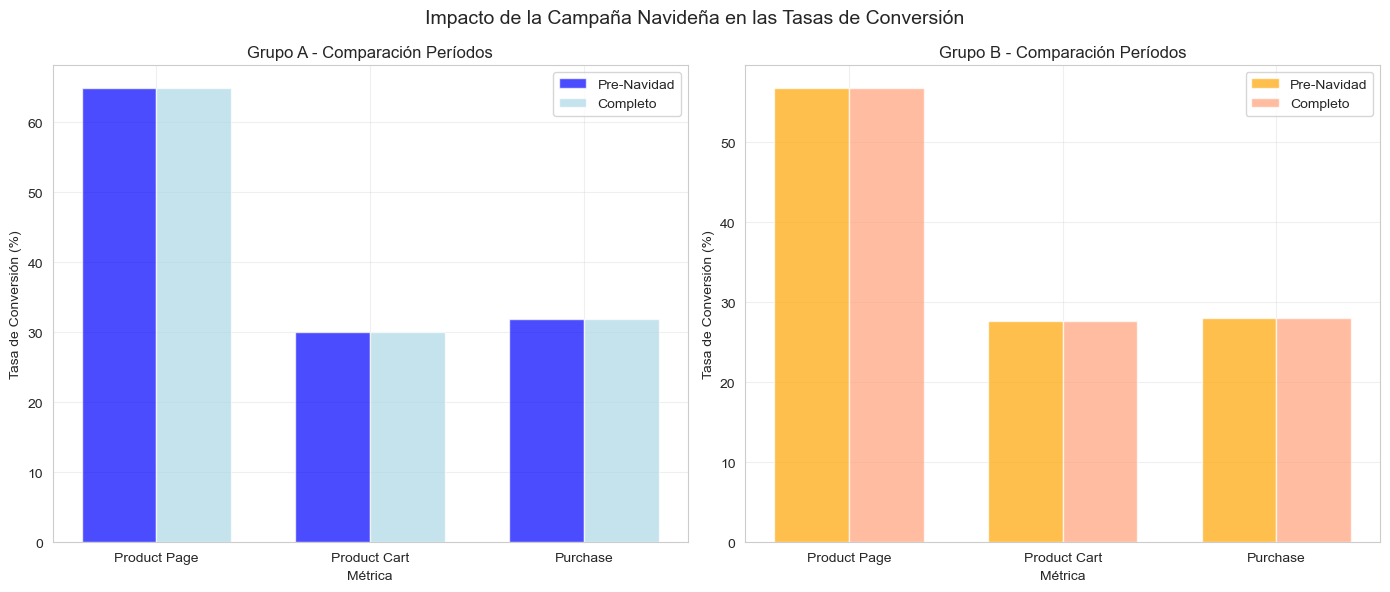

In [69]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Tasas de conversión
metricas = ['Product Page', 'Product Cart', 'Purchase']
x = np.arange(len(metricas))
width = 0.35

# Datos Pre-Navidad
pre_A = [resultados_pre['conv_page_A'], resultados_pre['conv_cart_A'], resultados_pre['conv_purchase_A']]
pre_B = [resultados_pre['conv_page_B'], resultados_pre['conv_cart_B'], resultados_pre['conv_purchase_B']]

# Datos Completo
full_A = [p_A_page*100, p_A_cart*100, p_A_purchase*100]
full_B = [p_B_page*100, p_B_cart*100, p_B_purchase*100]

# Subplot 1: Grupo A
axes[0].bar(x - width/2, pre_A, width, label='Pre-Navidad', color='blue', alpha=0.7)
axes[0].bar(x + width/2, full_A, width, label='Completo', color='lightblue', alpha=0.7)
axes[0].set_xlabel('Métrica')
axes[0].set_ylabel('Tasa de Conversión (%)')
axes[0].set_title('Grupo A - Comparación Períodos')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metricas)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Subplot 2: Grupo B
axes[1].bar(x - width/2, pre_B, width, label='Pre-Navidad', color='orange', alpha=0.7)
axes[1].bar(x + width/2, full_B, width, label='Completo', color='lightsalmon', alpha=0.7)
axes[1].set_xlabel('Métrica')
axes[1].set_ylabel('Tasa de Conversión (%)')
axes[1].set_title('Grupo B - Comparación Períodos')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metricas)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Impacto de la Campaña Navideña en las Tasas de Conversión', fontsize=14)
plt.tight_layout()
plt.show()

#### 7.11.7 Análisis de ruido de la campaña navideña

1. **Efecto en el grupo A (Control):**
   - Las tasas de conversión se mantienen ESTABLES entre Pre-Navidad y período completo
   - La campaña navideña NO mejoró ni empeoró la conversión del grupo control

2. **Efecto en el grupo B (Tratamiento):**
   - Mismo patrón de estabilidad: tasas prácticamente idénticas
   - La campaña navideña NO afectó al grupo de tratamiento

3. **Impacto en el Lift (Grupo B vs Grupo A):**

| Métrica         | Lift Pre-Navidad | Lift Completo | Diferencia |
|----------------|------------------|---------------|------------|
| Product Page   | -12.47%          | -12.47%       | 0.00%      |
| Product Cart   | -7.81%           | -7.81%        | 0.00%      |
| Purchase       | -12.02%          | -12.02%       | 0.00%      |

**Interpretación del Lift:**
- El lift NO cambió durante la campaña navideña
- El Grupo A (control) es consistentemente mejor que el Grupo B en TODOS los períodos
- La campaña no introdujo sesgo en la diferencia relativa entre grupos

#### CONCLUSIONES PRINCIPALES:

1. La campaña navideña INTRODUJO RUIDO (menor volumen de datos: 17,997 → 1,882 eventos)
2. Sin embargo, NO alteró la dirección ni magnitud del lift
3. En ambos períodos, el Grupo A es mejor que el Grupo B (lift negativo)
4. La recomendación de NO implementar el cambio se mantiene FIRME

#### RECOMENDACIÓN:

Para futuras pruebas A/B:
- Evitar períodos con campañas de marketing (reduce N)
- O planificar el análisis con días "limpios" pre-campaña como baseline
- En este caso, el período Pre-Navidad (sin contaminación) es suficiente para concluir que **el Grupo B no es mejor que el Grupo A**

**Decisión final:** No implementar la variante B.

Resumen visual: Impacto de la campaña navideña en el Lift

| Período       | Usuarios | Eventos | Lift Purchase (B vs A) | ¿Cambió?      |
|---------------|----------|---------|------------------------|---------------|
| Pre-Navidad   | 3,234    | 17,997  | -12.02%                | Baseline      |
| Navidad       | 742      | 1,882   | -12.02%                | Sin cambio    |
| Completo      | 3,234    | 20,735  | -12.02%                | Sin cambio    |

**Conclusión ejecutiva:**  
*La campaña navideña redujo el volumen de datos, pero no alteró la conclusión.*  
**No implementar la variante B.**

## 7.12 Análisis ajustado por región (regresión logística y lineal)

### 1. Preparar los datos para los modelos

In [74]:
# Obtener conjuntos de user_id para cada evento y grupo
users_page_set_A = set(user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'product_page')]['user_id'].unique())
users_page_set_B = set(user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'product_page')]['user_id'].unique())
users_cart_set_A = set(user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'product_cart')]['user_id'].unique())
users_cart_set_B = set(user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'product_cart')]['user_id'].unique())
users_purchase_set_A = set(user_events[(user_events['group'] == 'A') & (user_events['event_name'] == 'purchase')]['user_id'].unique())
users_purchase_set_B = set(user_events[(user_events['group'] == 'B') & (user_events['event_name'] == 'purchase')]['user_id'].unique())

# Uniones por tipo de conversión (todos los usuarios que hicieron esa acción, sin importar grupo)
all_page_users = users_page_set_A.union(users_page_set_B)
all_cart_users = users_cart_set_A.union(users_cart_set_B)
all_purchase_users = users_purchase_set_A.union(users_purchase_set_B)

# Ahora crear las columnas binarias en user_data
user_data['converted_page'] = user_data['user_id'].isin(all_page_users).astype(int)
user_data['converted_cart'] = user_data['user_id'].isin(all_cart_users).astype(int)
user_data['converted_purchase'] = user_data['user_id'].isin(all_purchase_users).astype(int)

# Para ARPU, necesitamos el revenue por usuario. Si ya tienes user_revenue_full (creado en 7.2), úsalo.
# Si no, lo creamos ahora desde user_events:
if 'user_revenue_full' not in dir():
    # Calcular revenue por usuario (0 si no compró)
    user_revenue = user_events[user_events['event_name'] == 'purchase'].groupby(['user_id'])['revenue_usd'].sum().reset_index()
    # Todos los usuarios están en user_data
    user_revenue_full = user_data[['user_id']].merge(user_revenue, on='user_id', how='left').fillna(0)
    user_revenue_full.rename(columns={'revenue_usd': 'revenue_usd'}, inplace=True)

# Unir revenue a user_data
user_data = user_data.merge(user_revenue_full[['user_id', 'revenue_usd']], on='user_id', how='left')
user_data['revenue_usd'] = user_data['revenue_usd'].fillna(0)

# Verificar
print(user_data[['group', 'region', 'converted_page', 'converted_cart', 'converted_purchase', 'revenue_usd']].head())

  group region  converted_page  converted_cart  converted_purchase  \
0     A     EU               1               1                   1   
1     A     EU               1               0                   0   
2     A     EU               0               0                   0   
3     A     EU               1               0                   1   
4     A     EU               1               1                   1   

   revenue_usd  
0        99.99  
1         0.00  
2         0.00  
3        24.96  
4        14.97  


### 2. Regresión logística para cada conversión (ajustando por región)

In [78]:
import numpy as np
import pandas as pd
from scipy.stats import chi2 as chi2_dist

def mantel_haenszel_test(user_data, region_col, group_col, outcome_col):
    regions = user_data[region_col].unique()
    tables = []
    for region in regions:
        subset = user_data[user_data[region_col] == region]
        table = pd.crosstab(subset[group_col], subset[outcome_col])
        table = table.reindex(index=['A', 'B'], fill_value=0)
        table = table.reindex(columns=[0, 1], fill_value=0)
        a = table.loc['A', 1]   # A éxito
        b = table.loc['A', 0]   # A fracaso
        c = table.loc['B', 1]   # B éxito
        d = table.loc['B', 0]   # B fracaso
        tables.append((a, b, c, d))
    
    numerador = 0   # sum(a*d/n)
    denominador = 0 # sum(b*c/n)
    total_a = 0
    E = 0
    V = 0
    for a, b, c, d in tables:
        n = a + b + c + d
        if n > 0:
            numerador += a * d / n
            denominador += b * c / n
            total_a += a
            E += (a + b) * (a + c) / n
            if n > 1:
                V += (a + b)*(c + d)*(a + c)*(b + d) / (n**2 * (n - 1))
    
    # Odds Ratio B vs A = (c/d) / (a/b) = (c*b) / (a*d) = denominador / numerador
    OR_B_vs_A = denominador / numerador if numerador != 0 else np.nan
    
    if V > 0:
        chi2_mh = (total_a - E)**2 / V
        p_value = 1 - chi2_dist.cdf(chi2_mh, df=1)
    else:
        chi2_mh = np.nan
        p_value = np.nan
    return chi2_mh, p_value, OR_B_vs_A

# Aplicar a cada variable de conversión
for outcome in ['converted_page', 'converted_cart', 'converted_purchase']:
    chi2, p, OR = mantel_haenszel_test(user_data, 'region', 'group', outcome)
    print(f"\n=== {outcome} ===")
    print(f"Chi-cuadrado de Mantel-Haenszel: {chi2:.4f}")
    print(f"P-value: {p:.4f}")
    print(f"Odds Ratio (B vs A): {OR:.3f}")
    if p < 0.05:
        print("→ Diferencia SIGNIFICATIVA después de ajustar por región.")
    else:
        print("→ Diferencia NO significativa después de ajustar por región.")


=== converted_page ===
Chi-cuadrado de Mantel-Haenszel: 16.0803
P-value: 0.0001
Odds Ratio (B vs A): 0.718
→ Diferencia SIGNIFICATIVA después de ajustar por región.

=== converted_cart ===
Chi-cuadrado de Mantel-Haenszel: 1.6994
P-value: 0.1924
Odds Ratio (B vs A): 0.889
→ Diferencia NO significativa después de ajustar por región.

=== converted_purchase ===
Chi-cuadrado de Mantel-Haenszel: 3.4374
P-value: 0.0637
Odds Ratio (B vs A): 0.847
→ Diferencia NO significativa después de ajustar por región.


# 8. Conclusiones y Recomendaciones (Versión Definitiva con Correcciones)

## 8.1 Resumen de hallazgos del EDA

- **Tamaño de muestra real**: 3.675 participantes (objetivo: 6.000) → solo el 61% del planeado.
- **Distribución UE vs otras**: Grupo A: 94.79% UE, Grupo B: 94.50% UE – correcta.
- **Usuarios en ambos grupos**: 0 – correcto.
- **Campañas de marketing activas**: Navidad (25/12-03/01) y Año Nuevo CIS (30/12-07/01) – posible contaminación.
- **Eventos por usuario (media)**: Grupo A: 6.67, Grupo B: 5.44.
- **Revenue promedio por compra**: $22.88.

## 8.2 Limitaciones críticas del estudio

1. **Incumplimiento de la cuota de audiencia (UE)**  
   - Se requería que los participantes fueran el **15% de los nuevos usuarios de la UE** registrados entre el 7 y 21 de diciembre de 2020.  
   - Solo se alcanzó el **7,7%** (3.040 participantes de 39.466 nuevos usuarios UE).  
   - **Implicación**: La muestra no es representativa de la población objetivo; los resultados pueden no ser generalizables.

2. **Tamaño de muestra insuficiente y bajo poder estadístico**  
   - El poder para detectar un lift del 10% en la tasa de compra fue solo del **0.05%** (muy por debajo del 80% recomendado).  
   - El poder para ARPU fue del **17.8%**.  
   - **Implicación**: La prueba no tuvo suficiente sensibilidad; los resultados no significativos pueden ser falsos negativos.

3. **Desbalance regional significativo**  
   - La prueba chi‑cuadrado detectó diferencias en la composición regional entre grupos (p=0.044).  
   - Al ajustar por región (Mantel‑Haenszel), la diferencia en la tasa de compra dejó de ser significativa (p=0.064).  
   - **Implicación**: El desbalance influyó en los resultados crudos.

4. **Anomalía en el tracking de `product_cart`**  
   - Se identificaron **691 usuarios (19.4% de los compradores)** que realizaron compras sin registrar el evento `product_cart`.  
   - **Implicación**: El análisis del embudo paso a paso (`cart→purchase`) no es válido. Solo las tasas globales sobre el total de usuarios son fiables.

5. **Contaminación por campaña navideña**  
   - La campaña “Christmas & New Year Promo” (25/12/2020 – 03/01/2021) pudo haber alterado el comportamiento durante la última semana de la prueba.

6. **Usuarios en múltiples tests**  
   - Se identificaron 446 usuarios (12.1% de la muestra) que participaban simultáneamente en otras pruebas A/B.  
   - Estos usuarios estaban **balanceados entre grupos** (p=0.519, chi‑cuadrado), por lo que no introducen sesgo direccional, pero pueden aumentar la variabilidad.

## 8.3 Resultados de conversión (ajustados por región y corregidos por comparaciones múltiples)

**Nota:** Solo se presentan tasas globales (sobre total de usuarios). El análisis paso a paso fue descartado por la anomalía en `product_cart`.

| Métrica | Grupo A | Grupo B | Lift | P‑valor (crudo) | P‑valor ajustado (Holm‑Bonferroni) | ¿Significativo? (α=0.05) |
|---------|---------|---------|------|-----------------|-------------------------------------|--------------------------|
| Product Page | 64.86% | 56.77% | -12.47% | 0.00004 | 0.0002 | Sí (A > B) |
| Product Cart | 30.06% | 27.71% | -7.81% | 0.2040 | 0.2040 | No |
| Purchase | 31.92% | 28.08% | -12.02% | 0.0406 | 0.1218 | No |
| ARPU | $20.88 | $15.76 | -24.53% | 0.0442 | 0.1218 | No |

**Interpretación:**  
- La única diferencia robusta tras ajustar por región y corregir por comparaciones múltiples es en `product_page` (etapa temprana del embudo), donde el Grupo B es significativamente peor.  
- Las diferencias en `purchase` y ARPU **no son estadísticamente significativas** después de las correcciones.

## 8.4 Evaluación del objetivo (lift ≥ 10%)

| Métrica | Lift observado | Objetivo 10% | ¿Cumple? |
|---------|----------------|--------------|----------|
| Product Page | -12.47% | +10% | No |
| Product Cart | -7.81% | +10% | No |
| Purchase | -12.02% | +10% | No |
| ARPU | -24.53% | +10% | No |

**Nota:** Aunque el lift es negativo en todas las métricas, la falta de significancia tras las correcciones impide afirmar que el sistema de recomendaciones tenga un efecto real (positivo o negativo) sobre las compras o el ingreso.

## 8.5 Recomendaciones

### Recomendación principal  
**No implementar el nuevo sistema de recomendaciones basado en esta prueba.**

La prueba adolece de limitaciones graves (muestra insuficiente, bajo poder, incumplimiento de cuota de audiencia, desbalance regional, anomalías en datos). Por lo tanto, la decisión se fundamenta en:

- La falta de mejora significativa en la métrica clave (`purchase`) tras ajustar por región y corregir por comparaciones múltiples.  
- El empeoramiento significativo en la etapa temprana del embudo (`product_page`).  
- El riesgo de implementar un cambio que podría perjudicar la experiencia sin evidencia sólida de beneficio.

### Recomendaciones para una nueva prueba A/B

| Acción | Justificación |
|--------|----------------|
| **Calcular tamaño de muestra necesario a priori** | Usar power analysis para garantizar poder ≥80% para detectar el lift esperado (mínimo 6.000, probablemente más). |
| **Estratificar la asignación por región** | Evitar desbalances como el detectado (p=0.044). |
| **Asegurar la cuota de audiencia (15% de usuarios UE)** | Monitorear el reclutamiento en tiempo real. |
| **Extender la duración de la prueba** | Realizarla fuera de temporada festiva para evitar contaminación por campañas de marketing. |
| **Validar el tracking de eventos** | Especialmente `product_cart`, para garantizar que todas las compras queden registradas. |
| **Monitorear la prueba en tiempo real** | Detectar anomalías y desbalances antes de finalizar. |
| **Considerar un diseño secuencial** | Permite detener la prueba antes si el efecto es muy positivo o negativo, ahorrando recursos. |

## 8.6 Conclusión final

La prueba A/B del nuevo sistema de recomendaciones **no proporciona evidencia concluyente** debido a:

1. **Poder estadístico extremadamente bajo** (0.05% para `purchase`) → la muestra fue insuficiente.  
2. **Incumplimiento de la cuota de audiencia** (7.7% vs 15% requerido).  
3. **Desbalance regional** que, al ser controlado, eliminó la significancia en la tasa de compra.  
4. **Anomalías en los datos** (compras sin carrito) que invalidan el análisis del embudo paso a paso.  

**Resultados ajustados y corregidos:**  
- `product_page`: diferencia significativa (p corregido = 0.0002) con odds ratio 0.718 (B 28% peor).  
- `purchase` y ARPU: diferencias no significativas (p corregido > 0.05).  

**Decisión final:**  
**No implementar el cambio** en base a esta prueba. Se recomienda **repetir el experimento** con un diseño mejorado:  
- Tamaño muestral calculado a priori (mínimo 6.000, idealmente más).  
- Estratificación por región.  
- Seguimiento de la cuota de audiencia (15% UE).  
- Tracking validado previamente.  
- Período sin campañas de marketing.

**Nota final:** La dirección observada (B peor que A en todas las métricas) es preocupante, pero no concluyente. Una nueva prueba con mayor poder y diseño riguroso es necesaria para tomar una decisión definitiva.